# GND multifractal — filter comparison

Copy of `ebsd_wtmm_pergrain_pantleon.ipynb` with the slip-system NNLS / tensor WTMM / Kantelhardt / RQA pipeline stripped. Goal: hold the GND computation pipeline fixed, vary the orientation noise-reduction filter, and compare the resulting scalar-GND multifractal spectra (D(h), Δh, c₂, c₃) across filters.

Filters: identity (no filter), Gaussian (σ=0.5, 1.0), Kuwahara 5×5 (edge-preserving nonlinear), Bilateral.

Argument that shift in absolute h doesn't matter: we report only spectrum-shape invariants (Δh, asymmetry, c₂, c₃) which are unchanged under uniform Hölder shift. Kuwahara/bilateral are *nonlinear* so the shift is not perfectly uniform — this notebook is the empirical control that tests how non-uniform.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fftfreq
import ipywidgets as widgets
from IPython.display import display
import sys

import mlx.core as mx

sys.path.insert(0, 'XSmurfWrapper')
import xsmurf_wrapper as xsm

print(f"MLX: {mx.__version__}, xsmurf: {xsm.__version__}")
# --- Shear-zone additions ---
try:
    from orix.quaternion import Orientation, Rotation
    from orix.quaternion.symmetry import D2, D3, C1
    _HAS_ORIX = True
    print(f'orix available for rotation + symmetry ops')
except ImportError:
    _HAS_ORIX = False
    print('orix not in this env — rotation + KAM fall back to pure-numpy path')

JOSEPHINE_ROTATION_XLSX = Path('EBSD/Josephine_Peridotite_Olivine/1365-3_RotationMetadata.xlsx')
EBSD_DIR = Path('/Users/amasaryk/projects/Creep/wavelet/EBSD')


In [ ]:
def compute_scales(n_oct, n_vox, a_min=1):
    norm = 6.0 / 0.86
    return [a_min * (2.0 ** (o + v / n_vox)) * norm
            for o in range(n_oct) for v in range(n_vox)]

def _build_wavelet_filters_f32(kx, ky, scale, wavelet='gaussian'):
    sx = kx * scale
    sy = ky * scale
    gauss = mx.exp(-(sx * sx + sy * sy))
    zero = mx.zeros_like(gauss)
    def to_complex(r, i):
        return mx.stack([r, i], axis=-1).view(mx.complex64).squeeze(-1)
    if wavelet == 'mexican':
        k2 = sx * sx + sy * sy
        return {
            'dx':  to_complex(zero, sx * k2 * gauss),
            'dy':  to_complex(zero, sy * k2 * gauss),
            'dxx':  to_complex(-sx * sx * k2 * gauss, zero),
            'dxy':  to_complex(-sy * sx * k2 * gauss, zero),
            'dyy':  to_complex(-sy * sy * k2 * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * k2 * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * k2 * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * k2 * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * k2 * gauss),
        }
    else:
        return {
            'dx':  to_complex(zero, sx * gauss),
            'dy':  to_complex(zero, sy * gauss),
            'dxx':  to_complex(-sx * sx * gauss, zero),
            'dxy':  to_complex(-sy * sx * gauss, zero),
            'dyy':  to_complex(-sy * sy * gauss, zero),
            'dxxx': to_complex(zero, -sx * sx * sx * gauss),
            'dxxy': to_complex(zero, -sx * sx * sy * gauss),
            'dxyy': to_complex(zero, -sx * sy * sy * gauss),
            'dyyy': to_complex(zero, -sy * sy * sy * gauss),
        }

def cwt_2d_f32(image, scales, pad=32, derivs='first', wavelet='gaussian', verbose=True):
    """2D CWT via MLX FFT. derivs='first' for dx,dy only; 'all' for up to 3rd order."""
    ny, nx = image.shape
    padded = np.pad(image, pad, mode='reflect').astype(np.float32)
    ny_p, nx_p = padded.shape
    crop = (slice(pad, pad + ny), slice(pad, pad + nx))
    kx_np = fftfreq(nx_p).astype(np.float32)
    ky_np = fftfreq(ny_p).astype(np.float32)
    KX_np, KY_np = np.meshgrid(kx_np, ky_np)
    KX, KY = mx.array(KX_np), mx.array(KY_np)
    image_fft = mx.fft.fft2(mx.array(padded))
    if derivs == 'first':
        names = ['dx', 'dy']
    else:
        names = ['dx', 'dy', 'dxx', 'dxy', 'dyy', 'dxxx', 'dxxy', 'dxyy', 'dyyy']
    n_scales = len(scales)
    result = {n: np.zeros((n_scales, ny, nx), dtype=np.float32) for n in names}
    result['mod'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    result['arg'] = np.zeros((n_scales, ny, nx), dtype=np.float32)
    for i, scale in enumerate(scales):
        filters = _build_wavelet_filters_f32(KX, KY, scale, wavelet=wavelet)
        for name in names:
            conv = mx.fft.ifft2(image_fft * filters[name])
            result[name][i] = np.array(conv.real)[crop]
        dx_s, dy_s = result['dx'][i], result['dy'][i]
        result['mod'][i] = np.sqrt(dx_s * dx_s + dy_s * dy_s)
        result['arg'][i] = np.arctan2(dy_s, dx_s).astype(np.float32)
        if verbose and (i % max(1, n_scales // 4) == 0 or i == n_scales - 1):
            print(f'  Scale {i}/{n_scales-1}: a={scale:.1f}')
    mx.eval()
    return result

def tensor_svd_3x2(gx1, gy1, gx2, gy2, gx3, gy3):
    """SVD of 3x2 Jacobian at every pixel via closed-form J^T J eigenvalues."""
    a = gx1*gx1 + gx2*gx2 + gx3*gx3
    b = gx1*gy1 + gx2*gy2 + gx3*gy3
    d = gy1*gy1 + gy2*gy2 + gy3*gy3
    trace = a + d
    det = a * d - b * b
    disc = np.sqrt(np.maximum((trace / np.float32(2))**2 - det, np.float32(0)))
    lambda1 = trace / np.float32(2) + disc
    lambda2 = np.maximum(trace / np.float32(2) - disc, np.float32(0))
    sigma_max = np.sqrt(np.maximum(lambda1, np.float32(0))).astype(np.float32)
    sigma_min = np.sqrt(lambda2).astype(np.float32)
    vx = lambda1 - d
    vy = b
    vnorm = np.sqrt(vx**2 + vy**2) + np.float32(1e-30)
    arg = np.arctan2(vy / vnorm, vx / vnorm).astype(np.float32)
    return sigma_max, sigma_min, arg

from xsmurf_wrapper.wavelet import gkapa_numpy, gkapap_numpy


print('CWT (first + all derivs) + tensor SVD + kapa/kapap functions defined')


In [ ]:
%matplotlib widget


In [ ]:
def read_ctf(filepath):
    """Read an Oxford Instruments .ctf (Channel Text File) EBSD dataset.
    
    Returns
    -------
    data : dict with 2D arrays for each field + metadata dict
    """
    filepath = Path(filepath)
    with open(filepath, 'r', errors='replace') as f:
        lines = f.readlines()

    meta = {'filepath': str(filepath), 'name': filepath.stem}
    phases = {}
    header_line = None

    for i, line in enumerate(lines):
        stripped = line.strip()
        if stripped.startswith('XCells'):
            meta['xcells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('YCells'):
            meta['ycells'] = int(stripped.split('\t')[1])
        elif stripped.startswith('XStep'):
            meta['xstep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('YStep'):
            meta['ystep'] = float(stripped.split('\t')[1])
        elif stripped.startswith('Phases'):
            n_phases = int(stripped.split('\t')[1])
            for j in range(1, n_phases + 1):
                phases[j] = lines[i + j].strip().split('\t')
            meta['phases'] = phases
            meta['n_phases'] = n_phases
        elif stripped.startswith('Phase\tX\tY'):
            header_line = i
            break

    if header_line is None:
        raise ValueError(f"Could not find data header in {filepath}")

    # Read tabular data
    df = pd.read_csv(filepath, sep='\t', skiprows=header_line, engine='python',
                     on_bad_lines='skip')
    
    nx, ny = meta['xcells'], meta['ycells']
    expected = nx * ny
    actual = len(df)
    if actual != expected:
        print(f"  Warning: expected {expected} rows ({nx}x{ny}), got {actual}")
        # Truncate or pad
        if actual > expected:
            df = df.iloc[:expected]
        else:
            nx_adj = actual // ny if ny > 0 else nx
            meta['xcells'] = nx_adj
            nx = nx_adj

    data = {'meta': meta}
    shape = (ny, nx)
    for col in df.columns:
        try:
            data[col] = df[col].values.reshape(shape)
        except ValueError:
            data[col] = df[col].values  # keep flat if reshape fails

    # Convenience aliases
    data['euler1'] = data.get('Euler1', None)
    data['euler2'] = data.get('Euler2', None)
    data['euler3'] = data.get('Euler3', None)
    data['bc'] = data.get('BC', None)
    data['bs'] = data.get('BS', None)
    data['mad'] = data.get('MAD', None)
    data['phase'] = data.get('Phase', None)

    print(f"  Loaded {filepath.name}: {nx} x {ny}, step={meta.get('xstep','?')} µm, "
          f"{meta.get('n_phases','?')} phases")
    return data
# --- Oxford Instruments Channel 5 .cpr/.crc binary reader ---
# Pure-numpy reader for .cpr (ASCII INI metadata) + .crc (binary data) pairs.
# Field code mapping taken from defdap.file_readers.OxfordBinaryLoader source.
# Unlike defdap's loader, this one does NOT construct a crystal Phase object
# so it works for any Laue group (including trigonal quartz, monoclinic
# feldspars, etc.) that the narrow defdap Phase class would reject.

import re as _re_cpr

_CPR_FIELD_LOOKUP = {
    3:  ('ph1',      'float32'),   # Euler1 phi1 (rad)
    4:  ('phi',      'float32'),   # Euler2 Phi  (rad)
    5:  ('ph2',      'float32'),   # Euler3 phi2 (rad)
    6:  ('MAD',      'float32'),   # mean angular deviation
    7:  ('BC',       'uint8'),     # band contrast
    8:  ('BS',       'uint8'),     # band slope
    10: ('numBands', 'uint8'),
    11: ('AFI',      'uint8'),
    12: ('IB6',      'float32'),
}


def _parse_cpr_ini(cpr_path):
    text = Path(cpr_path).read_text(errors='replace')
    groups = {}
    current = None
    group_re = _re_cpr.compile(r'^\[(.+)\]\s*$')
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith(';'):
            continue
        m = group_re.match(line)
        if m:
            current = m.group(1)
            groups.setdefault(current, {})
            continue
        if current is None:
            continue
        if '=' in line:
            k, v = line.split('=', 1)
            groups[current][k.strip()] = v.strip()
    return groups


def read_cpr(filepath):
    """Read an Oxford Instruments .cpr/.crc file pair.

    Returns the same dict shape as read_ctf():
        meta          dict with xcells, ycells, xstep, ystep, phases, n_phases, name
        euler1/2/3    (ny, nx) float32 arrays in DEGREES
        phase         (ny, nx) uint8 array
        bc, bs, mad   (ny, nx) arrays if present
        Plus any EDX windows as EDX_<element> keys.
    """
    filepath = Path(filepath)
    cpr_path = filepath.with_suffix('.cpr')
    crc_path = filepath.with_suffix('.crc')
    if not cpr_path.exists():
        raise FileNotFoundError(f"CPR header not found: {cpr_path}")
    if not crc_path.exists():
        raise FileNotFoundError(f"CRC binary not found: {crc_path}")

    groups = _parse_cpr_ini(cpr_path)

    # Grid & step
    job = groups.get('Job', {})
    nx = int(job['xCells'])
    ny = int(job['yCells'])
    xstep = float(job.get('GridDistX', 1.0))
    ystep = float(job.get('GridDistY', xstep))

    # Phases: assemble ctf-like metadata so downstream cells keep working
    pg = groups.get('Phases', {})
    n_phases = int(pg.get('Count', 0))
    phases = {}
    for i in range(1, n_phases + 1):
        pi = groups.get(f'Phase{i}', {})
        lattice = '{};{};{}'.format(pi.get('a', '?'), pi.get('b', '?'), pi.get('c', '?'))
        angles = '{};{};{}'.format(pi.get('alpha', '?'), pi.get('beta', '?'), pi.get('gamma', '?'))
        phases[i] = [lattice, angles,
                     pi.get('StructureName', f'phase_{i}'),
                     pi.get('LaueGroup', '?'), pi.get('SpaceGroup', '?')]

    # EDX window names (field codes 100+i)
    edx_names = {}
    edx_group = groups.get('EDX Windows', {})
    if edx_group:
        n_edx = int(edx_group.get('Count', 0))
        for i in range(1, n_edx + 1):
            key = edx_group.get(f'Window{i}', f'edx{i}')
            edx_names[100 + i] = key

    # Build the binary record dtype from the [Fields] section
    fg = groups.get('Fields', {})
    n_fields = int(fg.get('Count', 0))
    dtype_items = [('phase', 'uint8')]   # phase is always first, uint8
    unknown = 0
    for i in range(1, n_fields + 1):
        code = int(fg[f'Field{i}'])
        if code in _CPR_FIELD_LOOKUP:
            dtype_items.append(_CPR_FIELD_LOOKUP[code])
        elif code in edx_names:
            dtype_items.append((f'EDX_{edx_names[code]}', 'float32'))
        else:
            unknown += 1
            dtype_items.append((f'unknown_{unknown}_code{code}', 'float32'))
            print(f'  warning: unknown CPR field code {code}, guessing float32')
    record_dtype = np.dtype(dtype_items)

    # Load binary
    raw = np.fromfile(str(crc_path), dtype=record_dtype, count=nx * ny)
    if raw.size != nx * ny:
        raw = raw[:nx * ny]
        print(f'  warning: CRC short read ({raw.size} records)')

    shape = (ny, nx)
    data = {'meta': {
        'filepath': str(filepath),
        'name': filepath.stem,
        'xcells': nx, 'ycells': ny,
        'xstep': xstep, 'ystep': ystep,
        'phases': phases, 'n_phases': n_phases,
        'format': 'cpr',
    }}

    data['phase'] = raw['phase'].reshape(shape)

    # CPR stores Euler in radians; convert to degrees to match ctf convention
    for raw_key, deg_key in [('ph1', 'euler1'), ('phi', 'euler2'), ('ph2', 'euler3')]:
        if raw_key in raw.dtype.names:
            data[deg_key] = np.rad2deg(raw[raw_key].reshape(shape)).astype(np.float32)

    if 'MAD' in raw.dtype.names: data['mad'] = raw['MAD'].reshape(shape)
    if 'BC'  in raw.dtype.names: data['bc']  = raw['BC'].reshape(shape)
    if 'BS'  in raw.dtype.names: data['bs']  = raw['BS'].reshape(shape)
    if 'numBands' in raw.dtype.names: data['bands'] = raw['numBands'].reshape(shape)
    for name in raw.dtype.names:
        if name.startswith('EDX_'):
            data[name] = raw[name].reshape(shape)

    print(f'  CPR: {nx}x{ny} @ {xstep} um, {n_phases} phases, {len(dtype_items)} fields')
    return data


def read_ebsd(filepath):
    """Dispatch to the right EBSD reader based on file extension."""
    filepath = Path(filepath)
    ext = filepath.suffix.lower()
    if ext == '.ctf':
        return read_ctf(filepath)
    elif ext in ('.cpr', '.crc'):
        return read_cpr(filepath)
    else:
        raise ValueError(f"Unsupported EBSD extension: {ext} (expected .ctf or .cpr/.crc)")


In [ ]:
EBSD_DIR = Path('EBSD')

# --- Loadable files: .ctf (ASCII) and .cpr (Oxford binary via read_cpr) ---
ctf_files = sorted(EBSD_DIR.rglob('*.ctf'))
cpr_files = sorted(EBSD_DIR.rglob('*.cpr'))
ebsd_files = sorted(ctf_files + cpr_files, key=lambda p: (p.parts[:-1], p.name))

# Shear-zone folder tags
SHEAR_ZONE_TAGS = {
    'Calamita_Elba_Quartzite':           ('[CAL]', 'Calamita quartzite'),
    'Kuckaus_Namibia_Feldspar_Mylonite': ('[KUC]', 'Kuckaus polymineralic mylonite'),
    'Josephine_Peridotite_Olivine':      ('[JOS]', 'Josephine peridotite'),
}

def _tag(path):
    rel = path.relative_to(EBSD_DIR)
    root = rel.parts[0] if rel.parts else ''
    return SHEAR_ZONE_TAGS.get(root, ('[...]', root))[0]

labels = []
for p in ebsd_files:
    rel = p.relative_to(EBSD_DIR)
    labels.append(f'{_tag(p)} {rel}  [{p.suffix[1:]}]')

print(f'Found {len(ebsd_files)} EBSD files ({len(ctf_files)} CTF + {len(cpr_files)} CPR):\n')
from collections import defaultdict
by_tag = defaultdict(list)
for i, p in enumerate(ebsd_files):
    by_tag[_tag(p)].append(i)
for tag, idxs in by_tag.items():
    print(f'  {tag}  ({len(idxs)} files)')
    for i in idxs:
        rel = ebsd_files[i].relative_to(EBSD_DIR)
        print(f'    [{i:3d}] {rel}  [{ebsd_files[i].suffix[1:]}]')
    print()


In [ ]:
# ---- Pick a dataset by index ----
DATASET_IDX = 20# <-- change this to select a different file

ebsd_path = ebsd_files[DATASET_IDX]
ctf_path = ebsd_path                        # alias: downstream cells look at ctf_path
print(f'Selected: {labels[DATASET_IDX]}')
print(f'  Path: {ebsd_path}')

ebsd = read_ebsd(ebsd_path)
meta = ebsd['meta']


In [ ]:
# ===== KAM via orix (symmetry-aware) =====

from orix.quaternion import Orientation
from orix.quaternion.symmetry import C1, C2, D2, D3, D6, C4, Oh

# ---------- USER PARAMETERS ----------
KAM_KERNEL = 1   # Kernel radius: 1 = 3x3, 2 = 5x5, 3 = 7x7, etc.
# --------------------------------------

LAUE_TO_ORIX = {
    '1': C1, '2': C2, '3': D2, '6': D3, '7': D6, '9': Oh, '11': C1,
}

def get_phase_symmetry(ebsd_data, phase_id=1):
    phases = ebsd_data['meta'].get('phases', {})
    if phase_id in phases:
        info = phases[phase_id]
        laue_str = str(info[3]).strip() if len(info) > 3 else '?'
        sym = LAUE_TO_ORIX.get(laue_str, None)
        name = info[2] if len(info) > 2 else f'phase_{phase_id}'
        print(f'  Phase {phase_id}: {name}, Laue={laue_str} -> {sym}')
        return sym
    return None


def compute_kam_orix(e1_deg, e2_deg, e3_deg, symmetry, mask=None,
                      kernel=1, degrees=True):
    """Compute KAM using orix Orientation.angle_with().

    kernel: neighborhood radius in pixels.
        1 = 3x3 (8 neighbors), 2 = 5x5 (24 neighbors), etc.
        Matches MTEX/OIM convention.
    """
    ny, nx = e1_deg.shape
    euler_rad = np.deg2rad(np.stack([e1_deg, e2_deg, e3_deg], axis=-1)).astype(np.float64)

    ori = Orientation.from_euler(euler_rad.reshape(-1, 3), symmetry=symmetry)
    ori = ori.reshape(ny, nx)

    kam = np.zeros((ny, nx), dtype=np.float64)
    count = np.zeros((ny, nx), dtype=np.float64)

    if mask is None:
        mask = np.ones((ny, nx), dtype=bool)

    # Generate all (dy, dx) offsets within the kernel radius
    offsets = []
    for dy in range(-kernel, kernel + 1):
        for dx in range(-kernel, kernel + 1):
            if dy == 0 and dx == 0:
                continue
            # Only count each pair once: (dy,dx) and (-dy,-dx) are the same pair
            if (dy, dx) > (0, 0) or (dy == 0 and dx > 0):
                offsets.append((dy, dx))

    print(f'  Kernel={kernel} -> {2*kernel+1}x{2*kernel+1}, {len(offsets)} unique neighbor pairs')

    for dy, dx in offsets:
        # Slice pairs so ori1[i,j] is compared with ori2[i,j] = ori1[i+dy, j+dx]
        if dy >= 0:
            sy1 = slice(None, ny - dy) if dy > 0 else slice(None)
            sy2 = slice(dy, None) if dy > 0 else slice(None)
        else:
            sy1 = slice(-dy, None)
            sy2 = slice(None, ny + dy)

        if dx >= 0:
            sx1 = slice(None, nx - dx) if dx > 0 else slice(None)
            sx2 = slice(dx, None) if dx > 0 else slice(None)
        else:
            sx1 = slice(-dx, None)
            sx2 = slice(None, nx + dx)

        o1 = ori[sy1, sx1]
        o2 = ori[sy2, sx2]
        m = mask[sy1, sx1] & mask[sy2, sx2]

        if not m.any():
            continue

        angles = np.full(o1.shape, np.nan)
        angles[m] = o1[m].angle_with(o2[m])
        v = np.isfinite(angles)
        a = np.where(v, angles, 0)

        kam[sy1, sx1] += a
        kam[sy2, sx2] += a
        count[sy1, sx1] += v
        count[sy2, sx2] += v

    kam = np.where(count > 0, kam / count, 0)
    kam[~mask] = np.nan
    if degrees:
        kam = np.rad2deg(kam)
    return kam


# --- Compute KAM for current dataset ---
phase_map = ebsd['phase']
unique_phases, phase_counts = np.unique(phase_map, return_counts=True)
dominant_phase = unique_phases[np.argmax(phase_counts)]
print(f'Phases: {dict(zip(unique_phases, phase_counts))}')
print(f'Dominant phase: {dominant_phase}')

sym = get_phase_symmetry(ebsd, phase_id=dominant_phase)
if sym is None:
    for pid in unique_phases:
        sym = get_phase_symmetry(ebsd, phase_id=int(pid))
        if sym is not None:
            dominant_phase = int(pid)
            break
if sym is None:
    print('WARNING: could not determine symmetry, using C1')
    sym = C1

phase_mask = (phase_map == dominant_phase)
print(f'Phase mask: {phase_mask.sum()}/{phase_mask.size} ({phase_mask.mean():.1%})')

print(f'Computing KAM (kernel={KAM_KERNEL})...')
kam = compute_kam_orix(ebsd['euler1'], ebsd['euler2'], ebsd['euler3'],
                        symmetry=sym, mask=phase_mask,
                        kernel=KAM_KERNEL, degrees=True)
print(f'KAM: [{np.nanmin(kam):.4f}, {np.nanmax(kam):.4f}] deg, median={np.nanmedian(kam):.4f}')

ny, nx = kam.shape
aspect = ny / nx
fig_w = 14
fig_h = max(4, fig_w * aspect * 0.45)

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h))
axes[0].imshow(ebsd['bc'], cmap='gray', aspect='equal')
axes[0].set_title('Band contrast')
im = axes[1].imshow(kam, cmap='hot', vmin=0, vmax=np.nanpercentile(kam, 95), aspect='equal')
axes[1].set_title(f'KAM (kernel={KAM_KERNEL}, {sym})')
plt.colorbar(im, ax=axes[1], label='degrees', shrink=0.7)
axes[2].hist(kam[np.isfinite(kam)].ravel(), bins=100,
             range=(0, np.nanpercentile(kam, 99)))
axes[2].set(xlabel='KAM (deg)', ylabel='count', title='KAM distribution')
for ax in axes[:2]: ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ===== Quaternion helpers (shared) =====
def _quat_mul(a, b):
    """Hamilton product.  Broadcasts over leading dims.  Last dim = 4 (w, x, y, z)."""
    aw, ax, ay, az = a[..., 0], a[..., 1], a[..., 2], a[..., 3]
    bw, bx, by, bz = b[..., 0], b[..., 1], b[..., 2], b[..., 3]
    return np.stack([
        
        aw * bw - ax * bx - ay * by - az * bz,
        aw * bx + ax * bw + ay * bz - az * by,
        aw * by - ax * bz + ay * bw + az * bx,
        aw * bz + ax * by - ay * bx + az * bw,
    ], axis=-1)

def _quat_conj(q):
    out = q.copy()
    out[..., 1:] *= -1.0
    return out


## Grain identification (adjacency flood-fill, no kernels)

In [ ]:
# ===== Grain identification via symmetry-aware adjacency flood-fill =====
# No kernels / windows: pixel neighbors only.  scipy.ndimage.label on a
# "same grain" adjacency graph built from per-neighbor misorientation.

from scipy.ndimage import label as ndi_label

# ---- parameters ----
GRAIN_THETA_DEG   = 7.0  # high-angle GB threshold (deg); 2 deg for subgrains
GRAIN_MIN_PIXELS  = 10    # drop grains smaller than this (stats only)
# ---------------------

def _sym_miso_angle(q_a, q_b, sym_q):
    """Symmetry-reduced misorientation angle between two quaternion arrays.
    q_a, q_b: (N, 4) unit quaternions.  sym_q: (S, 4) symmetry ops.
    Returns (N,) angles in radians (smallest under the point group)."""
    q_rel = _quat_mul(_quat_conj(q_a), q_b)           # (N, 4)
    q_sym = _quat_mul(q_rel[:, None, :], sym_q[None, :, :])  # (N, S, 4)
    w = np.abs(q_sym[..., 0])                         # (N, S)
    w_max = np.clip(w.max(axis=1), -1.0, 1.0)
    return 2.0 * np.arccos(w_max)

def identify_grains(ebsd_data, theta_c_deg=GRAIN_THETA_DEG):
    """Symmetry-aware grain segmentation.
    Returns: grain_id (ny, nx) int32 (0 = unindexed/background, ≥1 = grain id).
    Algorithm:
      - for each phase, compute pixel-right and pixel-down misorientation (adjacency only)
      - threshold to build 'same grain' edge graph
      - connected-components label within phase
      - concatenate grain ids across phases with unique offsets
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    # Build unit quaternion map (from Euler via orix)
    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q *= np.where(q[..., 0:1] >= 0, 1.0, -1.0)

    theta_c = np.deg2rad(theta_c_deg)
    grain_id = np.zeros((ny, nx), dtype=np.int32)
    gid_offset = 0

    for pid in [int(p) for p in np.unique(phase) if int(p) > 0]:
        pmask = (phase == pid)
        if pmask.sum() < GRAIN_MIN_PIXELS:
            continue
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        # Right-neighbor misorientation: between (y, x) and (y, x+1)
        a = q[:, :-1, :].reshape(-1, 4)
        b = q[:,  1:, :].reshape(-1, 4)
        theta_right = _sym_miso_angle(a, b, sym_q).reshape(ny, nx - 1)

        # Down-neighbor misorientation: between (y, x) and (y+1, x)
        a = q[:-1, :, :].reshape(-1, 4)
        b = q[ 1:, :, :].reshape(-1, 4)
        theta_down = _sym_miso_angle(a, b, sym_q).reshape(ny - 1, nx)

        # Build same-phase adjacency: both pixels must be in this phase
        both_r = pmask[:, :-1] & pmask[:, 1:]
        both_d = pmask[:-1, :] & pmask[1:, :]

        # Same-grain edges
        same_r = both_r & (theta_right < theta_c)
        same_d = both_d & (theta_down  < theta_c)

        # Expand edge flags to a 4-connected adjacency-friendly mask:
        # a pixel is "connected to its right/down neighbor" iff same_r/same_d is True.
        # scipy.ndimage.label can use a custom structure on a binary image, but we
        # want connectivity conditional on edge labels.  Easiest: build a pseudo-pixel
        # structure by union-find over edges.
        # Use a lightweight Union-Find implementation.
        n_pix = ny * nx
        parent = np.arange(n_pix, dtype=np.int64)

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        def union(i, j):
            ri, rj = find(i), find(j)
            if ri != rj:
                parent[rj] = ri

        ys, xs = np.where(same_r)
        for y, x in zip(ys, xs):
            union(y * nx + x, y * nx + (x + 1))

        ys, xs = np.where(same_d)
        for y, x in zip(ys, xs):
            union(y * nx + x, (y + 1) * nx + x)

        # Harvest roots → local labels
        roots = np.array([find(i) for i in range(n_pix)], dtype=np.int64)
        # Only keep labels inside phase mask
        ravel_mask = pmask.ravel()
        # Remap roots to 1..K
        uniq_roots, inv = np.unique(roots[ravel_mask], return_inverse=True)
        local_lbl = np.zeros(n_pix, dtype=np.int32)
        local_lbl[ravel_mask] = inv.astype(np.int32) + 1
        local_lbl = local_lbl.reshape(ny, nx)

        # Offset and assign
        n_this = int(local_lbl.max())
        lbl_off = np.where(local_lbl > 0, local_lbl + gid_offset, 0)
        grain_id[pmask] = lbl_off[pmask]
        gid_offset += n_this

    return grain_id


# ---- Run ----
grain_id = identify_grains(ebsd, theta_c_deg=GRAIN_THETA_DEG)
n_grains_total = int(grain_id.max())
sizes = np.bincount(grain_id.ravel())[1:]  # skip background
n_big = int((sizes >= GRAIN_MIN_PIXELS).sum())
print(f'Grains found: {n_grains_total} total, {n_big} with >= {GRAIN_MIN_PIXELS} px')
print(f'Median grain size: {int(np.median(sizes)) if len(sizes) else 0} px, '
      f'max: {int(sizes.max()) if len(sizes) else 0} px')


## Per-grain demean + log orientation

In [ ]:
# ===== Per-grain Karcher mean + demean + log orientation =====
# Per-grain symmetry-aware mean reference; log map reduces to FZ.

# ---- options ----
CAXIS_TO_Z = False     # rotate each grain reference so c-axis || sample Z (quartz only)
FZ_WARN_FRAC = 0.7    # warn when per-pixel disorientation exceeds this fraction of FZ max
# -----------------

# FZ max disorientation (deg) per point group (approximate, proper rotation group)
FZ_MAX_DEG_BY_NAME = {
    'D6h': 93.8, 'D6': 93.8, 'C6h': 93.8, 'C6': 93.8,
    'D4h': 98.4, 'D4': 98.4, 'C4h': 98.4, 'C4': 98.4,
    'D3d': 104.5, 'D3': 104.5, 'C3v': 104.5, 'C3': 120.0,
    'D2h': 120.7, 'D2': 120.7, 'C2h': 180.0, 'C2': 180.0,
    'Ci':  180.0, 'C1':  180.0,
    'Oh':  62.8, 'O':  62.8, 'Td': 62.8, 'Th': 62.8, 'T': 62.8,
    'S6':  180.0, 'S4': 180.0, 'Cs':  180.0,
}

def _karcher_mean_grain(q_grain, sym_q, max_iter=5, tol=1e-4):
    """Symmetry-aware Karcher mean of unit quaternions within a grain."""
    n = len(q_grain)
    q_grain = q_grain * np.where(q_grain[:, 0:1] >= 0, 1.0, -1.0)
    # Seed = orientation tensor dominant eigenvector
    T = (q_grain.T @ q_grain) / n
    _, eigvecs = np.linalg.eigh(T)
    q_ref = eigvecs[:, -1]
    if q_ref[0] < 0:
        q_ref = -q_ref
    for _ in range(max_iter):
        # Choose symmetry-equivalent closest to q_ref for each pixel
        q_sym = _quat_mul(q_grain[:, None, :], sym_q[None, :, :])  # (N, S, 4)
        rel = _quat_mul(_quat_conj(q_ref)[None, None, :], q_sym)
        rel *= np.where(rel[..., 0:1] >= 0, 1.0, -1.0)
        best = np.argmax(rel[..., 0], axis=1)
        q_aligned = q_sym[np.arange(n), best]
        q_aligned *= np.where(q_aligned[:, 0:1] >= 0, 1.0, -1.0)
        T = (q_aligned.T @ q_aligned) / n
        _, eigvecs = np.linalg.eigh(T)
        q_new = eigvecs[:, -1]
        if q_new[0] < 0:
            q_new = -q_new
        if abs(float(q_ref @ q_new)) > 1.0 - tol:
            break
        q_ref = q_new
    return q_ref, q_aligned

def _rotation_to_align_caxis_with_z(q_ref):
    """Return quaternion r such that (r * q_ref) places crystal c-axis along sample Z.
    Crystal c-axis in crystal frame = (0, 0, 1).  Rotate crystal frame by q_ref
    into sample frame; we then want r so that r composed with the rotated c-axis
    points along sample Z.  Implementation: compute rotated c-axis, then rigid
    rotation bringing that vector to (0, 0, 1)."""
    # Rotate (0, 0, 1) by q_ref: v = q_ref * (0,0,0,1) * q_ref^-1
    w, x, y, z = q_ref
    # Quaternion rotation of unit z-axis:
    vx = 2.0 * (x * z + w * y)
    vy = 2.0 * (y * z - w * x)
    vz = 1.0 - 2.0 * (x * x + y * y)
    v = np.array([vx, vy, vz])
    v /= np.linalg.norm(v) + 1e-12
    z_axis = np.array([0.0, 0.0, 1.0])
    cosang = float(np.clip(v @ z_axis, -1.0, 1.0))
    if cosang > 1.0 - 1e-9:
        return np.array([1.0, 0.0, 0.0, 0.0])
    if cosang < -1.0 + 1e-9:
        return np.array([0.0, 1.0, 0.0, 0.0])  # 180 deg about x
    axis = np.cross(v, z_axis)
    axis /= np.linalg.norm(axis) + 1e-12
    ang = np.arccos(cosang)
    s = np.sin(ang / 2.0)
    return np.array([np.cos(ang / 2.0), axis[0] * s, axis[1] * s, axis[2] * s])

def compute_log_orientation_per_grain(ebsd_data, grain_id, caxis_to_z=CAXIS_TO_Z):
    """Per-grain demean + log map.
    Returns dict: grain_id -> {q_ref, q_align_rot, log_field_slice, mask, phase_id,
                                theta_p99_deg, fz_max_deg, fz_warn}
    Also returns a combined (ny, nx, 3) log field with per-grain demeaned values.
    """
    e1 = np.deg2rad(ebsd_data['euler1'].astype(np.float64))
    e2 = np.deg2rad(ebsd_data['euler2'].astype(np.float64))
    e3 = np.deg2rad(ebsd_data['euler3'].astype(np.float64))
    phase = ebsd_data['phase']
    ny, nx = e1.shape

    ori_all = Orientation.from_euler(np.stack([e1.ravel(), e2.ravel(), e3.ravel()], axis=1))
    q_map = ori_all.data.reshape(ny, nx, 4).astype(np.float64)
    q_map *= np.where(q_map[..., 0:1] >= 0, 1.0, -1.0)

    combined_log = np.zeros((ny, nx, 3), dtype=np.float32)
    combined_mask = np.zeros((ny, nx), dtype=bool)
    grain_info = {}

    gids = [int(g) for g in np.unique(grain_id) if int(g) > 0]
    print(f'Processing {len(gids)} grains...')

    for gi, gid in enumerate(gids):
        gmask = (grain_id == gid)
        n_pix = int(gmask.sum())
        if n_pix < GRAIN_MIN_PIXELS:
            continue
        ys, xs = np.where(gmask)
        pid = int(phase[ys[0], xs[0]])
        sym = get_phase_symmetry(ebsd_data, phase_id=pid)
        if sym is None:
            sym = C1
        sym_q = sym.data.astype(np.float64)

        q_grain = q_map[ys, xs, :]            # (n, 4)
        q_ref, q_aligned = _karcher_mean_grain(q_grain, sym_q)

        # Optional rigid rotation bringing c-axis || Z
        if caxis_to_z:
            r = _rotation_to_align_caxis_with_z(q_ref)
            # Apply r to q_ref and to aligned pixels: q' = r * q
            q_ref_new  = _quat_mul(r[None, :], q_ref[None, :])[0]
            q_aligned_new = _quat_mul(r[None, :], q_aligned)
        else:
            r = np.array([1.0, 0.0, 0.0, 0.0])
            q_ref_new = q_ref
            q_aligned_new = q_aligned

        # Disorientation: q_rel = q_ref^-1 * q_aligned  (already picked symmetry rep)
        rel = _quat_mul(_quat_conj(q_ref_new)[None, :], q_aligned_new)
        rel *= np.where(rel[:, 0:1] >= 0, 1.0, -1.0)
        w = np.clip(rel[:, 0], -1.0, 1.0)
        theta = 2.0 * np.arccos(w)
        sin_half = np.sqrt(np.maximum(1.0 - w * w, 0.0))
        small = sin_half < 1e-8
        safe = np.where(small, 1.0, sin_half)
        axis = rel[:, 1:4] / safe[:, None]
        axis[small] = 0.0
        omega = theta[:, None] * axis
        omega[small] = 2.0 * rel[small, 1:4]

        combined_log[ys, xs, :] = omega.astype(np.float32)
        combined_mask[ys, xs]   = True

        # FZ validity check
        sym_name = sym.__class__.__name__ if sym is not None else 'C1'
        fz_max = FZ_MAX_DEG_BY_NAME.get(sym_name, 180.0)
        p99 = float(np.rad2deg(np.percentile(theta, 99))) if n_pix else 0.0
        fz_warn = bool(p99 > FZ_WARN_FRAC * fz_max)

        grain_info[gid] = {
            'phase_id': pid,
            'n_pixels': n_pix,
            'q_ref': q_ref_new,
            'rot_to_z': r,
            'theta_p99_deg': p99,
            'fz_max_deg': fz_max,
            'fz_warn': fz_warn,
            'sym_name': sym_name,
        }

    n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
    if n_warn:
        print(f'  WARNING: {n_warn} grain(s) near FZ boundary (log chart may be unreliable).')
        print('  Consider splitting via subgrain segmentation (theta_c = 2 deg).')

    return combined_log, combined_mask, grain_info


combined_log, combined_mask, grain_info = compute_log_orientation_per_grain(
    ebsd, grain_id, caxis_to_z=CAXIS_TO_Z)
print(f'Combined per-grain log field: {combined_mask.sum()}/{combined_mask.size} pixels')
print(f'log_field  abs median: {np.median(np.abs(combined_log[combined_mask])):.4f}')
print(f'log_field  abs p99:    {np.percentile(np.abs(combined_log[combined_mask]), 99):.4f}')


## Visualize grains and log field

In [ ]:
# ===== Visualize grains and per-grain log-orientation field =====
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Grain map (distinct colors, background dark)
rng = np.random.default_rng(0)
colors = np.vstack([[0.1, 0.1, 0.1], rng.random((grain_id.max() + 1, 3))])
gmap = colors[grain_id]
ax = axes[0]
ax.imshow(gmap, interpolation='nearest')
ax.set_title(f'{int(grain_id.max())} grains')
ax.axis('off')

# (b) Log-orientation magnitude
mag = np.linalg.norm(combined_log, axis=2)
mag[~combined_mask] = np.nan
ax = axes[1]
im = ax.imshow(np.rad2deg(mag), cmap='viridis', vmin=0, vmax=np.nanpercentile(np.rad2deg(mag), 98))
plt.colorbar(im, ax=ax, label='|v| (deg)')
ax.set_title('Per-grain log disorientation magnitude')
ax.axis('off')

# (c) RGB coding of log vector direction
lv = combined_log.copy()
lv -= lv.min()
lv /= (lv.max() + 1e-9)
lv[~combined_mask] = 0
ax = axes[2]
ax.imshow(lv)
ax.set_title('log orientation (RGB)')
ax.axis('off')

plt.tight_layout()
plt.show()

# FZ-boundary-warning grains
n_warn = sum(1 for g in grain_info.values() if g['fz_warn'])
print(f'Grains flagged near FZ boundary: {n_warn}/{len(grain_info)}')


## MAD/CI quality mask

Drop pixels with bad pattern indexation BEFORE the wavelet sees them.
Bad indexations are *high-amplitude* outliers (orientation off by tens of degrees) — they survive WTMM `THRESH` and look like real h ≈ −1 singularities. Filtering by MAD or BC is the only way to remove them; smoothing won't.

Cutoffs: **MAD < 1.0°** and **BC > 50** (Oxford EBSD standard). The mask is AND'd into `combined_mask` so the per-grain demean already in place gets honored downstream.


In [ ]:
# ===== MAD / BC quality mask =====
MAD_MAX = 1.0    # degrees; Oxford convention, ~equivalent to TSL CI > 0.2
BC_MIN  = 50     # band-contrast minimum (0..255)

mad_field = ebsd.get('mad')
bc_field  = ebsd.get('bc')
quality_mask = np.ones(combined_mask.shape, dtype=bool)
if mad_field is not None:
    quality_mask &= (np.asarray(mad_field) < MAD_MAX)
    print(f'MAD < {MAD_MAX} deg: {(mad_field < MAD_MAX).mean()*100:.1f}% pass')
else:
    print('MAD not available; skipping MAD cut')
if bc_field is not None:
    quality_mask &= (np.asarray(bc_field) > BC_MIN)
    print(f'BC  > {BC_MIN}: {(bc_field > BC_MIN).mean()*100:.1f}% pass')
else:
    print('BC not available; skipping BC cut')

n_before = combined_mask.sum()
combined_mask = combined_mask & quality_mask
combined_log[~combined_mask] = 0.0   # zero out failed pixels in the log field
n_after = combined_mask.sum()
print(f'\nMask AND: {n_before} -> {n_after} valid pixels  '
      f'({100 * n_after / max(n_before, 1):.1f}% retained)')


## Filter zoo

Each filter takes the per-grain log-orientation field `combined_log` and the validity mask `combined_mask`, returns a smoothed copy. All filters are *masked* — they don't smear zeros from invalid pixels into valid neighbors.

- **identity**: no filter (baseline)
- **gaussian_0p5**: linear Gaussian, σ = 0.5 px (light)
- **gaussian_1p0**: linear Gaussian, σ = 1.0 px (medium)
- **kuwahara_5**: 5×5 Kuwahara (nonlinear, edge-preserving). Picks the   3×3 quadrant with lowest variance per pixel.
- **bilateral**: Gaussian-spatial × Gaussian-range (skimage). Edge-aware   but linear in range.

Joint-channel variance for Kuwahara: sum of per-channel variances (equivalent to Frobenius variance of the 3-vector).


In [ ]:
# ===== Filter zoo =====
import numpy as np
from scipy.ndimage import uniform_filter, gaussian_filter

def _masked_gaussian(field, mask, sigma):
    """Per-channel masked Gaussian: G(f * mask) / G(mask), zero outside mask."""
    out  = np.zeros_like(field)
    mskf = mask.astype(np.float64)
    weight = gaussian_filter(mskf, sigma) + 1e-12
    for c in range(field.shape[-1]):
        f_safe = np.where(mask, field[..., c], 0.0).astype(np.float64)
        out[..., c] = (gaussian_filter(f_safe, sigma) / weight).astype(field.dtype)
    out[~mask] = 0.0
    return out

def _masked_kuwahara_5(field, mask):
    """5x5 Kuwahara on a (ny, nx, n_ch) field.  Joint per-quadrant variance =
    sum of per-channel variances (Frobenius variance of the 3-vector).
    Quadrants: NW, NE, SW, SE — 3x3 sub-windows centered at offsets
    (-1,-1), (-1,1), (1,-1), (1,1) relative to the pixel."""
    ny, nx, n_ch = field.shape
    pad = 2
    mskf = mask.astype(np.float64)

    # Per-channel 3x3 mean and variance via uniform_filter on padded inputs
    # uniform_filter(size=3) outputs the mean of a 3x3 window centered at each pixel.
    means_3x3   = np.zeros((n_ch, ny + 2*pad, nx + 2*pad), dtype=np.float64)
    sq_3x3      = np.zeros_like(means_3x3)
    mskf_p      = np.pad(mskf, pad, mode='edge')
    weight_3x3  = uniform_filter(mskf_p, 3) + 1e-12

    for c in range(n_ch):
        fp  = np.pad(np.where(mask, field[..., c], 0.0).astype(np.float64),
                     pad, mode='edge')
        m   = uniform_filter(fp,        3) / weight_3x3
        m2  = uniform_filter(fp ** 2,   3) / weight_3x3
        means_3x3[c] = m
        sq_3x3[c]    = m2

    # joint Frobenius variance per 3x3 window
    var_3x3 = np.sum(sq_3x3 - means_3x3 ** 2, axis=0)   # shape (ny+2p, nx+2p)

    # 4 quadrant offsets
    offsets = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
    means_per_q = np.zeros((4, n_ch, ny, nx), dtype=np.float64)
    vars_per_q  = np.zeros((4, ny, nx),       dtype=np.float64)
    for q, (dr, dc) in enumerate(offsets):
        # quadrant mean for pixel (i, j) = mean of 3x3 window centered at (i+dr, j+dc)
        for c in range(n_ch):
            means_per_q[q, c] = means_3x3[c, pad + dr:pad + dr + ny,
                                              pad + dc:pad + dc + nx]
        vars_per_q[q] = var_3x3[pad + dr:pad + dr + ny,
                                 pad + dc:pad + dc + nx]

    # pick lowest-variance quadrant per pixel
    qbest = np.argmin(vars_per_q, axis=0)              # (ny, nx)
    out   = np.zeros_like(field)
    for c in range(n_ch):
        out[..., c] = np.take_along_axis(means_per_q[:, c],
                                          qbest[None, ...], axis=0)[0]
    out[~mask] = 0.0
    return out

def _masked_bilateral(field, mask, sigma_s=1.5, sigma_r=0.05):
    """Per-channel bilateral via skimage.  Falls back to gaussian if skimage
    is unavailable."""
    try:
        from skimage.restoration import denoise_bilateral
    except Exception:
        print('skimage not available; falling back to Gaussian sigma=1.0')
        return _masked_gaussian(field, mask, 1.0)
    out = np.zeros_like(field)
    for c in range(field.shape[-1]):
        f_safe = np.where(mask, field[..., c], 0.0).astype(np.float64)
        out[..., c] = denoise_bilateral(f_safe, sigma_color=sigma_r,
                                          sigma_spatial=sigma_s,
                                          mode='reflect').astype(field.dtype)
    out[~mask] = 0.0
    return out


FILTERS = {
    'identity':       lambda f, m: f.copy(),
    'gaussian_0p5':   lambda f, m: _masked_gaussian(f, m, 0.5),
    'gaussian_1p0':   lambda f, m: _masked_gaussian(f, m, 1.0),
    'kuwahara_5':     lambda f, m: _masked_kuwahara_5(f, m),
    'bilateral':      lambda f, m: _masked_bilateral(f, m, 1.5, 0.05),
}

print(f'{len(FILTERS)} filters configured: {list(FILTERS)}')


## Apply filters → `log_variants`

Apply each filter to `combined_log`. Visual sanity check: show channel 0 of each filtered variant side-by-side. Real grain interiors should look smoother in the filtered variants; grain boundaries should stay sharp in Kuwahara and bilateral, slightly softened in Gaussian.


In [ ]:
# ===== Apply filters =====
import time, matplotlib.pyplot as plt

log_variants = {}
for name, fn in FILTERS.items():
    t0 = time.perf_counter()
    log_variants[name] = fn(combined_log, combined_mask)
    print(f'{name:<14s}  done in {(time.perf_counter()-t0)*1e3:6.0f} ms  '
          f'mean abs = {np.mean(np.abs(log_variants[name][combined_mask])):.4f}')

# Visualize channel 0 (omega_x) of each variant
n_v = len(log_variants)
fig, axs = plt.subplots(1, n_v, figsize=(3.4 * n_v, 3.4), squeeze=False)
vmin, vmax = np.percentile(combined_log[combined_mask, 0], [2, 98])
for ax, (name, f) in zip(axs[0], log_variants.items()):
    fld = np.where(combined_mask, f[..., 0], np.nan)
    ax.imshow(fld, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.set_title(name, fontsize=10); ax.set_axis_off()
fig.suptitle(r'Filtered $\omega_x$ (per-grain log-orientation, channel 0)',
             fontsize=11)
fig.tight_layout(); plt.show()


## FD-Nye → scalar GND density per variant

For each filter variant, compute the Pantleon Nye tensor by finite difference on `combined_log_filtered` (Eq. 6 of Pantleon 2008): α_ik = κ_ki − δ_ik tr(κ), then scalar GND density ρ_GND = ‖α‖_F / b. Same `_assemble_alpha_ij` mapping as the canonical pantleon notebook.


In [ ]:
# ===== FD-Nye + scalar rho_GND per filter variant =====
def _assemble_alpha_ij(kappa_2x3):
    # kappa[..., j(0=x, 1=y), i(0..2)] = d g_i / d x_j
    # Returns alpha[..., i, k] in (ny, nx, 3, 3) per Pantleon Eq. 6 with kappa_i3 = 0.
    ny, nx = kappa_2x3.shape[:2]
    k = kappa_2x3
    alpha = np.zeros((ny, nx, 3, 3), dtype=np.float64)
    trace = k[..., 0, 0] + k[..., 1, 1]
    for i_ in range(3):
        for kk in range(3):
            delta = 1.0 if i_ == kk else 0.0
            if kk < 2:
                alpha[..., i_, kk] = k[..., kk, i_] - delta * trace
            else:
                alpha[..., i_, kk] = -delta * trace
    return alpha

px_um = ebsd.get('meta', {}).get('xstep', 1.0)

gnd_variants = {}
for name, log_filt in log_variants.items():
    ny_, nx_ = log_filt.shape[:2]
    kappa_2x3 = np.zeros((ny_, nx_, 2, 3), dtype=np.float64)
    for ci in range(3):
        kappa_2x3[..., 0, ci] = np.gradient(log_filt[..., ci], axis=1) / px_um
        kappa_2x3[..., 1, ci] = np.gradient(log_filt[..., ci], axis=0) / px_um
    alpha_3x3 = _assemble_alpha_ij(kappa_2x3)
    rho       = np.sqrt(np.sum(alpha_3x3 ** 2, axis=(-2, -1)))   # ||alpha||_F
    rho       = np.where(combined_mask, rho, np.nan)
    gnd_variants[name] = rho.astype(np.float32)
    valid     = combined_mask & np.isfinite(rho)
    print(f'{name:<14s}  rho_GND  median = {np.nanmedian(rho):.4e}  '
          f'p99 = {np.nanpercentile(rho, 99):.4e}  '
          f'mean = {np.nanmean(rho):.4e}')

# Visualize
n_v = len(gnd_variants)
fig, axs = plt.subplots(1, n_v, figsize=(3.4 * n_v, 3.4), squeeze=False)
all_finite = np.concatenate([rho[combined_mask & np.isfinite(rho)].ravel()
                              for rho in gnd_variants.values()])
vmax = np.percentile(all_finite, 98)
for ax, (name, rho) in zip(axs[0], gnd_variants.items()):
    ax.imshow(rho, cmap='inferno', vmin=0, vmax=vmax)
    ax.set_title(name, fontsize=10); ax.set_axis_off()
fig.suptitle(r'Scalar $\rho_{\rm GND} = \|\alpha\|_F$ per filter variant',
             fontsize=11)
fig.tight_layout(); plt.show()


## Scalar WTMM per variant

For each filter variant, run scalar WTMM on `ρ_GND`: CWT first derivatives at the same scale grid, NMS extrema, chain extraction, Hölder estimation. Same parameters across variants so the only thing changing is the input field.

Wall time: ~30–60 s per variant; 5 variants ≈ 3–5 min total.


In [147]:
# ===== Scalar WTMM per variant =====
from xsmurf_wrapper.anchor_chain import chain_and_extract
import xsmurf_wrapper as xsm

# WTMM parameters — kept fixed across variants
WTMM_FRACINT_ALPHA = 0      # pseudo-fractional integration
WTMM_PAD           = 32
WTMM_THRESH        = 1e-4
WTMM_A_MIN         = 1.0
WTMM_N_OCT         = 4
WTMM_N_VOX         = 6        # 24 scales total (lighter than pantleon)
WTMM_SIMILITUDE    = 0.8
WTMM_BORDER_PCT    = 2.0    # small safety margin; the inner-window filter does the real COI work
WTMM_INNER_WINDOW  = 256    # keep only chains anchored in central N×N window of each combined_log;
                            # CWT runs on the full field so wavelets near the window edge see real data,
                            # not mirrored padding.  Set to None to disable.
WTMM_DIST_FRAC     = 0.1
WTMM_SMOOTH_CHAIN  = True
WTMM_CHAIN_METHOD  = 'greedy'
WTMM_WAVELET       = 'gaussian'

scales = compute_scales(n_oct=WTMM_N_OCT, n_vox=WTMM_N_VOX, a_min=WTMM_A_MIN)
n_sc   = len(scales)
scales_um = np.array(scales) * px_um
print(f'{n_sc} scales: {scales_um[0]:.2f} ... {scales_um[-1]:.2f} um')


variant_results = {}
for name, rho in gnd_variants.items():
    print(f'\n--- {name} ---')
    # Replace NaN with median (rho is bounded; this is mild and the WTMM mask
    # respects pixel positions anyway -- for chain extraction we ignore NaN
    # via the threshold).
    rho_clean = np.where(np.isfinite(rho), rho, np.nanmedian(rho))
    rho_clean = rho_clean.astype(np.float32)

    print('  CWT first derivatives...')
    derivs = cwt_2d_f32(rho_clean, scales, pad=WTMM_PAD, derivs='first',
                         wavelet=WTMM_WAVELET, verbose=False)

    if WTMM_FRACINT_ALPHA != 0:
        for si, s in enumerate(scales):
            f = np.float32(s ** WTMM_FRACINT_ALPHA)
            derivs['dx'][si] *= f
            derivs['dy'][si] *= f

    # Build per-scale (mod, arg) and run NMS extrema
    print('  NMS extrema + chain extraction...')
    ext_images = []
    mod_stack  = np.zeros((n_sc, *rho_clean.shape), dtype=np.float32)
    for si, scale in enumerate(scales):
        dx_r = derivs['dx'][si]
        dy_r = derivs['dy'][si]
        mod_si = np.sqrt(dx_r * dx_r + dy_r * dy_r).astype(np.float32)
        mod_stack[si] = mod_si
        ext, _, _ = xsm.wtmm2d(xsm.XImage.from_numpy(dx_r),
                                xsm.XImage.from_numpy(dy_r),
                                scale, thresh=WTMM_THRESH)
        ext_images.append(ext)

    chains = chain_and_extract(
        ext_images, scales, method=WTMM_CHAIN_METHOD,
        a_min=WTMM_A_MIN, n_oct=WTMM_N_OCT, n_vox=WTMM_N_VOX,
        similitude=WTMM_SIMILITUDE, smooth=WTMM_SMOOTH_CHAIN,
        border_percent=WTMM_BORDER_PCT, dist_frac=WTMM_DIST_FRAC)

    # ----- Inner-window chain filter (COI elimination by windowing) -----
    if WTMM_INNER_WINDOW is not None:
        ny_full, nx_full = rho_clean.shape
        if ny_full < WTMM_INNER_WINDOW + 64 or nx_full < WTMM_INNER_WINDOW + 64:
            print(f'  WARN: field {ny_full}x{nx_full} too small for'
                  f' inner-window={WTMM_INNER_WINDOW}; using all chains')
        else:
            cy, cx = ny_full // 2, nx_full // 2
            half   = WTMM_INNER_WINDOW // 2
            y_lo, y_hi = cy - half, cy + half
            x_lo, x_hi = cx - half, cx + half
            n_pre = len(chains)
            chains_in = []
            for ch in chains:
                y0, x0 = int(ch['y'][0]), int(ch['x'][0])
                if (y_lo <= y0 < y_hi) and (x_lo <= x0 < x_hi):
                    chains_in.append(ch)
            chains = chains_in
            print(f'  inner-window filter [{y_lo}:{y_hi}, {x_lo}:{x_hi}]:'
                  f'  {n_pre} -> {len(chains)} chains'
                  f'  ({100*len(chains)/max(n_pre,1):.1f}% kept)')

    holders = xsm.compute_holder_exponents(chains)
    h_vals = [h['h'] for h in holders]
    print(f'  {len(chains)} chains, h_median = {np.median(h_vals):.3f}')

    variant_results[name] = {
        'rho': rho, 'mod_stack': mod_stack,
        'chains': chains, 'holders': holders,
    }
print('\nAll variants done.')


24 scales: 16.74 ... 238.68 um

--- identity ---
  CWT first derivatives...
  NMS extrema + chain extraction...
  WARN: field 310x414 too small for inner-window=256; using all chains
  2285 chains, h_median = -0.922

--- gaussian_0p5 ---
  CWT first derivatives...
  NMS extrema + chain extraction...
  WARN: field 310x414 too small for inner-window=256; using all chains
  2272 chains, h_median = -0.870

--- gaussian_1p0 ---
  CWT first derivatives...
  NMS extrema + chain extraction...
  WARN: field 310x414 too small for inner-window=256; using all chains
  2174 chains, h_median = -0.766

--- kuwahara_5 ---
  CWT first derivatives...
  NMS extrema + chain extraction...
  WARN: field 310x414 too small for inner-window=256; using all chains
  2323 chains, h_median = -0.931

--- bilateral ---
  CWT first derivatives...
  NMS extrema + chain extraction...
  WARN: field 310x414 too small for inner-window=256; using all chains
  2079 chains, h_median = -0.674

All variants done.


## fBm calibration — validate xsmurf wavelet normalization

Synthesize 2D fractional Brownian motion at known Hurst exponents
(H = 0.3, 0.5, 0.7) via spectral synthesis. Push each through the same
WTMM pipeline used on `ρ_GND` (CWT first-derivatives → NMS extrema →
chain extraction → `compute_holder_exponents`). **Expected: chain
`h_median ≈ H`.**

- If `h_median ≈ H` (within ~0.05): xsmurf is L¹-normalized, **report h
  values as measured** with no correction.
- If `h_median ≈ H + 1` (consistently): L² leak in 2D, subtract 1 from
  reported h for physical interpretation.
- If `h_median` deviates non-trivially in some other way: there's a
  third bug; investigate.

Once-only methods-section sanity check. Adds ~30 seconds to the runtime.



--- fBm calibration:  H = 0.3 ---
  CWT first derivatives...
  inner-window: 3953 -> 1000 chains
  N_chains:  1000
  h_median:  -0.254   (expected H = 0.3)
  h IQR:     [-0.604, -0.006]
  bias:      -0.554   (unknown)

--- fBm calibration:  H = 0.5 ---
  CWT first derivatives...
  inner-window: 3374 -> 830 chains
  N_chains:  830
  h_median:  -0.036   (expected H = 0.5)
  h IQR:     [-0.413, +0.203]
  bias:      -0.536   (unknown)

--- fBm calibration:  H = 0.7 ---
  CWT first derivatives...
  inner-window: 2755 -> 670 chains
  N_chains:  670
  h_median:  +0.228   (expected H = 0.7)
  h IQR:     [-0.088, +0.416]
  bias:      -0.472   (unknown)


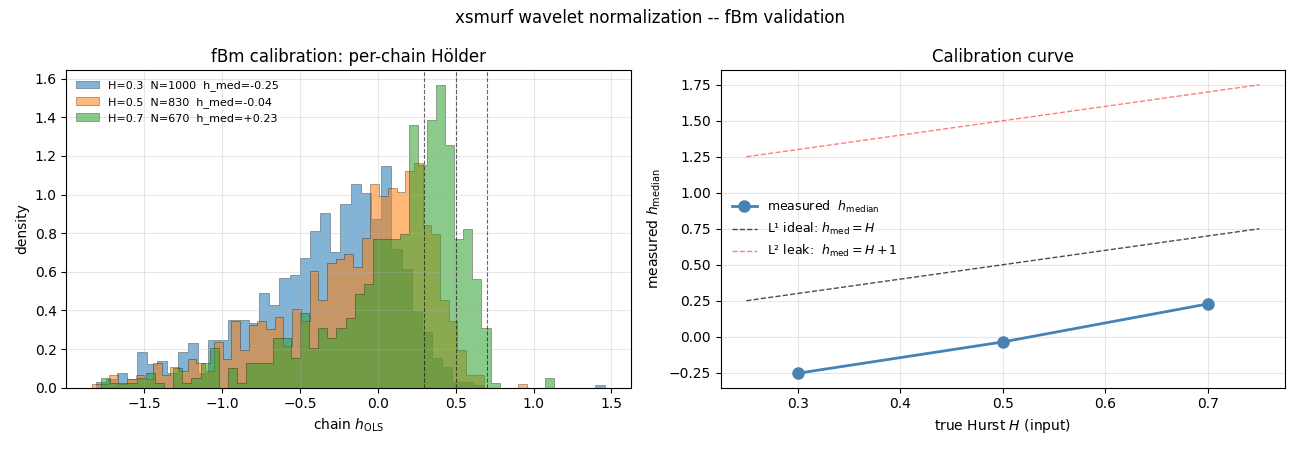


--- Calibration verdict ---
  Mean bias  =  -0.521
  --> Non-trivial bias of -0.521; investigate further.


In [148]:
# ===== fBm calibration =====
import numpy as np
import matplotlib.pyplot as plt

def _fbm_2d(N, H, seed=42):
    """Spectral synthesis of 2D fractional Brownian motion (approximate;
    no Wood-Chan circulant embedding -- adequate for normalization
    calibration where we care about the slope, not the exact tail
    statistics)."""
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal((N, N))
    F = np.fft.fft2(noise)
    kx = np.fft.fftfreq(N).reshape(-1, 1)
    ky = np.fft.fftfreq(N).reshape(1, -1)
    k_mag = np.sqrt(kx ** 2 + ky ** 2)
    k_mag[0, 0] = 1.0
    F = F / (k_mag ** (H + 1.0))
    F[0, 0] = 0.0
    return np.real(np.fft.ifft2(F)).astype(np.float32)

CALIB_H_VALUES = [0.3, 0.5, 0.7]
CALIB_N        = 512   # larger than WTMM_INNER_WINDOW=256 so the inner-window filter activates and chains are COI-free

calib_scales    = compute_scales(n_oct=WTMM_N_OCT, n_vox=WTMM_N_VOX,
                                   a_min=WTMM_A_MIN)
calib_results = {}

for H_true in CALIB_H_VALUES:
    print(f'\n--- fBm calibration:  H = {H_true} ---')
    fbm = _fbm_2d(CALIB_N, H_true)
    fbm = (fbm - fbm.mean()) / (fbm.std() + 1e-12)

    print('  CWT first derivatives...')
    cwt_c = cwt_2d_f32(fbm, calib_scales, pad=WTMM_PAD,
                        derivs='first', wavelet=WTMM_WAVELET, verbose=False)
    # NO fracint -- pure normalization test (eta = 0)

    ext_imgs = []
    for si, scale in enumerate(calib_scales):
        dx_r = cwt_c['dx'][si]
        dy_r = cwt_c['dy'][si]
        ext, _, _ = xsm.wtmm2d(xsm.XImage.from_numpy(dx_r),
                                 xsm.XImage.from_numpy(dy_r),
                                 scale, thresh=WTMM_THRESH)
        ext_imgs.append(ext)

    chains_c = chain_and_extract(
        ext_imgs, calib_scales, method=WTMM_CHAIN_METHOD,
        a_min=WTMM_A_MIN, n_oct=WTMM_N_OCT, n_vox=WTMM_N_VOX,
        similitude=WTMM_SIMILITUDE, smooth=WTMM_SMOOTH_CHAIN,
        border_percent=WTMM_BORDER_PCT, dist_frac=WTMM_DIST_FRAC)

    # Match the data-pipeline COI elimination: keep only chains anchored in
    # the central INNER_WINDOW.  CWT was computed on full N×N field so wavelets
    # at chain anchor positions see real data, not mirrored padding.
    if WTMM_INNER_WINDOW is not None and CALIB_N >= WTMM_INNER_WINDOW + 64:
        cy, cx = CALIB_N // 2, CALIB_N // 2
        half   = WTMM_INNER_WINDOW // 2
        y_lo, y_hi = cy - half, cy + half
        x_lo, x_hi = cx - half, cx + half
        n_pre = len(chains_c)
        chains_c = [ch for ch in chains_c
                     if (y_lo <= int(ch['y'][0]) < y_hi)
                    and (x_lo <= int(ch['x'][0]) < x_hi)]
        print(f'  inner-window: {n_pre} -> {len(chains_c)} chains')

    holders_c = xsm.compute_holder_exponents(chains_c)
    h_arr = np.array([h['h'] for h in holders_c if np.isfinite(h['h'])])
    h_med = float(np.median(h_arr)) if h_arr.size else np.nan
    h_iqr = (float(np.percentile(h_arr, 25)),
              float(np.percentile(h_arr, 75))) if h_arr.size else (np.nan, np.nan)
    bias  = h_med - H_true
    print(f'  N_chains:  {len(chains_c)}')
    print(f'  h_median:  {h_med:+.3f}   (expected H = {H_true})')
    print(f'  h IQR:     [{h_iqr[0]:+.3f}, {h_iqr[1]:+.3f}]')
    print(f'  bias:      {bias:+.3f}   '
           f"({'L¹ ok' if abs(bias) < 0.1 else 'L² leak suspect' if 0.7 < bias < 1.3 else 'unknown'})")
    calib_results[H_true] = {'h_arr': h_arr, 'h_med': h_med}


# ----- Visualize -----
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))

# Histograms
ax = axs[0]
for H_true, res in calib_results.items():
    h_arr = res['h_arr']
    if h_arr.size == 0: continue
    ax.hist(h_arr, bins=50, alpha=0.55, density=True, histtype='stepfilled',
              edgecolor='black', lw=0.4,
              label=f'H={H_true}  N={len(h_arr)}  h_med={res["h_med"]:+.2f}')
    ax.axvline(H_true, color='black', ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel(r'chain $h_{\rm OLS}$')
ax.set_ylabel('density')
ax.set_title(r'fBm calibration: per-chain Hölder')
ax.legend(fontsize=8, loc='best', frameon=False)
ax.grid(alpha=0.3)

# Calibration curve
ax = axs[1]
H_arr     = np.array(list(calib_results.keys()))
h_med_arr = np.array([calib_results[H]['h_med'] for H in H_arr])
ax.plot(H_arr, h_med_arr, 'o-', color='steelblue', lw=2, ms=8,
         label=r'measured  $h_{\rm median}$')
H_smooth = np.linspace(H_arr.min() - 0.05, H_arr.max() + 0.05, 50)
ax.plot(H_smooth, H_smooth, 'k--', lw=1, alpha=0.7,
         label=r'L¹ ideal: $h_{\rm med} = H$')
ax.plot(H_smooth, H_smooth + 1.0, 'r--', lw=1, alpha=0.5,
         label=r'L² leak:  $h_{\rm med} = H + 1$')
ax.set_xlabel('true Hurst $H$ (input)')
ax.set_ylabel(r'measured $h_{\rm median}$')
ax.set_title('Calibration curve')
ax.legend(fontsize=9, loc='best', frameon=False)
ax.grid(alpha=0.3)

fig.suptitle('xsmurf wavelet normalization -- fBm validation',
              fontsize=12)
fig.tight_layout(); plt.show()


# ----- Verdict -----
print('\n--- Calibration verdict ---')
mean_bias = float(np.mean(h_med_arr - H_arr))
print(f'  Mean bias  =  {mean_bias:+.3f}')
if abs(mean_bias) < 0.1:
    print('  --> L¹ normalization confirmed.  '
          'Report h values from your data as measured.')
elif 0.7 < mean_bias < 1.3:
    print('  --> L² leak confirmed (+d/2 = +1 shift in 2D).  '
          'Subtract 1 from your reported h values for physical interpretation.')
else:
    print(f'  --> Non-trivial bias of {mean_bias:+.3f}; investigate further.')


## Partition function + D(h) per variant

Build standard `Z(q,a) = Σ |W|^q` over chains for each variant. Linear-fit `log₂ Z` vs `log₂ a` over the same scale window to recover τ(q), `h(q) = dτ/dq`, `D(h) = q·h − τ`. Plot D(h) overlay across variants on shared axes; print Δh, asymmetry, and Venugopal cumulants c₁ / c₂ / c₃.

**The mathematically pure invariants are c₂ and c₃** — they don't shift under uniform Hölder shift `η_smooth`. c₁ does shift, by exactly `η_smooth`. If c₂ and c₃ are the same across filters but c₁ differs, the filter is acting as a clean uniform shift and the spectrum is robust. If c₂ varies between filters, the filter is *biasing* the intermittency — that's the nonlinearity caveat to watch for.



Venugopal cumulants  (c1 shifts under filter; c2, c3 are invariants)
----------------------------------------------------------------------
variant           c1 (h_med)   c2 (intmt)    c3 (asym)        Δh     asym
identity              -0.925       0.1773      +0.0400       nan     +nan
gaussian_0p5          -0.887       0.1747      +0.0180       nan     +nan
gaussian_1p0          -0.794       0.1869      +0.0073       nan     +nan
kuwahara_5            -0.938       0.1980      +0.0585       nan     +nan
bilateral             -0.701       0.1921      +0.0021       nan     +nan
----------------------------------------------------------------------
Readings:
  c2 stable across filters    -> intermittency is real (not noise)
  c2 collapses on smoothing   -> width was precision-floor noise
  c3 stable                   -> asymmetry is real signal
  c1 monotone with sigma      -> filter acts as uniform shift (linear filters)


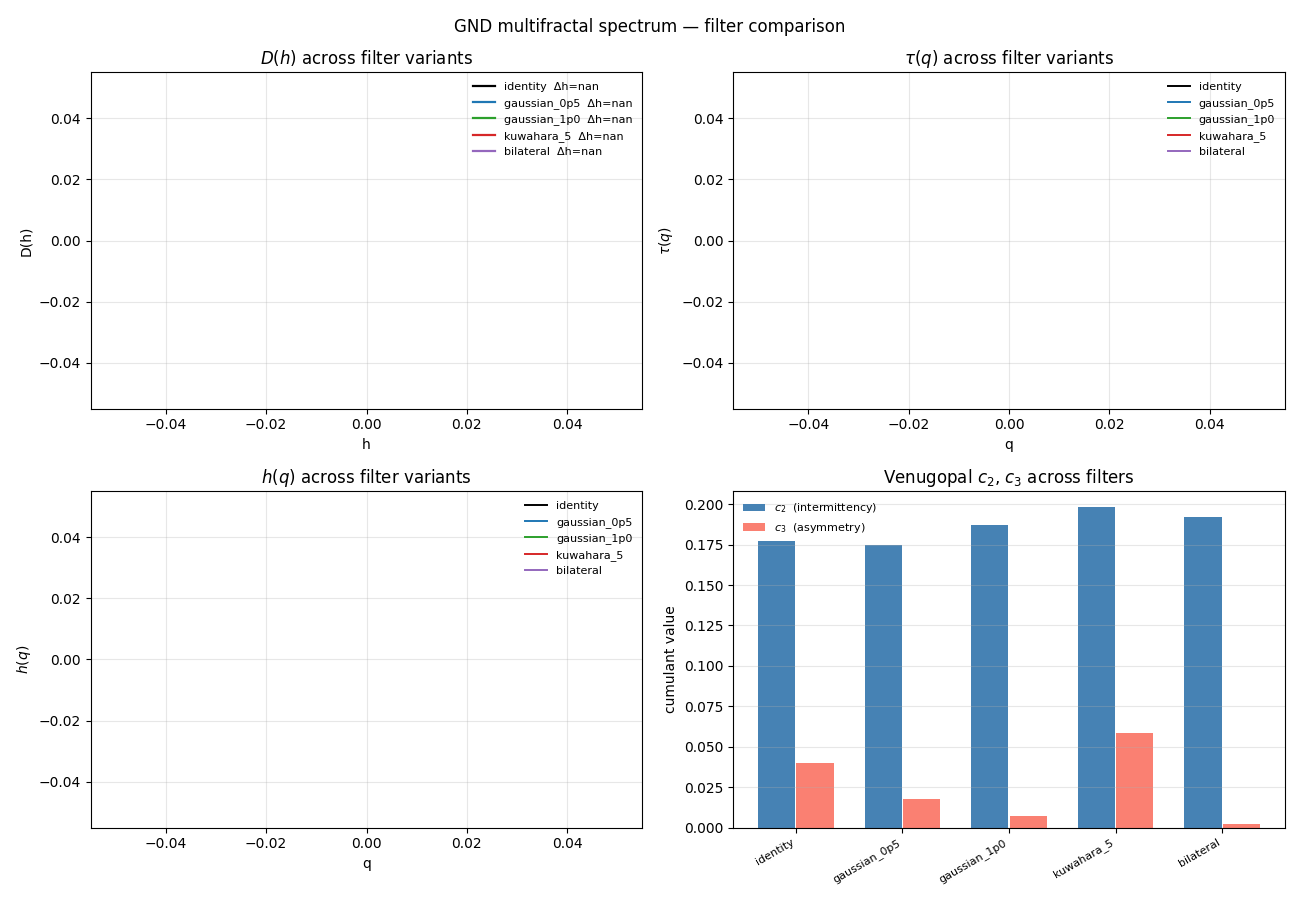

In [149]:
# ===== Partition function + D(h) overlay =====
FIT_SCALE_MIN_UM = 2.0
FIT_SCALE_MAX_UM = 16.0
Q_LIST = np.arange(-4.0, 4.05, 0.25)
n_q = len(Q_LIST)

log2_s = np.log2(scales_um)
fit_mask = (scales_um >= FIT_SCALE_MIN_UM) & (scales_um <= FIT_SCALE_MAX_UM)

def _compute_spectrum(chains, q_list, log2_s, fit_mask):
    Zqa = np.zeros((len(q_list), n_sc), dtype=np.float64)
    counts_a = np.zeros(n_sc, dtype=np.int64)
    for ch in chains:
        ls_ = np.asarray(ch['log2_scales']).astype(np.float64)
        lm_ = np.asarray(ch['log2_mod']).astype(np.float64)
        for k in range(len(ls_)):
            si = int(np.argmin(np.abs(log2_s - ls_[k])))
            counts_a[si] += 1
            M = 2.0 ** lm_[k]
            if M > 0:
                Zqa[:, si] += M ** q_list
    tau = np.full(len(q_list), np.nan)
    for qi in range(len(q_list)):
        yy = np.log2(np.maximum(Zqa[qi], 1e-300))
        v  = fit_mask & np.isfinite(yy) & (counts_a > 5)
        if v.sum() >= 3:
            coef = np.polyfit(log2_s[v], yy[v], 1)
            tau[qi] = coef[0]
    h_q = np.gradient(tau, q_list)
    D_q = q_list * h_q - tau
    return tau, h_q, D_q

# Venugopal cumulants from chain holders
def _cumulants(holders):
    h = np.array([x['h'] for x in holders if np.isfinite(x['h'])])
    if len(h) < 30:
        return [np.nan, np.nan, np.nan]
    c1 = float(np.mean(h))
    c2 = float(np.var(h))
    c3 = float(np.mean((h - c1) ** 3))
    return [c1, c2, c3]

variant_spectra = {}
for name, res in variant_results.items():
    tau, h_q, D_q = _compute_spectrum(res['chains'], Q_LIST, log2_s, fit_mask)
    cums = _cumulants(res['holders'])
    valid = np.isfinite(h_q) & np.isfinite(D_q)
    if valid.sum() >= 3:
        delta_h = float(np.nanmax(h_q[valid]) - np.nanmin(h_q[valid]))
    else:
        delta_h = np.nan
    h_peak = h_q[np.nanargmax(D_q)] if valid.any() else np.nan
    asym   = float((np.nanmean(h_q[valid]) - h_peak)) if valid.any() else np.nan
    variant_spectra[name] = {'tau': tau, 'h_q': h_q, 'D_q': D_q,
                             'cums': cums, 'delta_h': delta_h, 'asym': asym}

# Plot overlay
_PALETTE = {'identity': '#000000', 'gaussian_0p5': '#1f77b4',
            'gaussian_1p0': '#2ca02c', 'kuwahara_5': '#d62728',
            'bilateral': '#9467bd'}

fig, axs = plt.subplots(2, 2, figsize=(13, 9))

# D(h) overlay
ax = axs[0, 0]
for name, sp in variant_spectra.items():
    col = _PALETTE.get(name, 'gray')
    ax.plot(sp['h_q'], sp['D_q'], color=col, lw=1.6,
             label=f"{name}  Δh={sp['delta_h']:.2f}")
ax.set_xlabel('h'); ax.set_ylabel('D(h)')
ax.set_title(r'$D(h)$ across filter variants')
ax.legend(fontsize=8, loc='best', frameon=False)
ax.grid(alpha=0.3)

# tau(q)
ax = axs[0, 1]
for name, sp in variant_spectra.items():
    col = _PALETTE.get(name, 'gray')
    ax.plot(Q_LIST, sp['tau'], color=col, lw=1.4, label=name)
ax.set_xlabel('q'); ax.set_ylabel(r'$\tau(q)$')
ax.set_title(r'$\tau(q)$ across filter variants')
ax.legend(fontsize=8, loc='best', frameon=False)
ax.grid(alpha=0.3)

# h(q)
ax = axs[1, 0]
for name, sp in variant_spectra.items():
    col = _PALETTE.get(name, 'gray')
    ax.plot(Q_LIST, sp['h_q'], color=col, lw=1.4, label=name)
ax.set_xlabel('q'); ax.set_ylabel(r'$h(q)$')
ax.set_title(r'$h(q)$ across filter variants')
ax.legend(fontsize=8, loc='best', frameon=False)
ax.grid(alpha=0.3)

# Cumulant bar chart (c2 = intermittency, the headline filter-invariant)
ax = axs[1, 1]
fnames = list(variant_spectra.keys())
c2_vals  = [variant_spectra[n]['cums'][1] for n in fnames]
c3_vals  = [variant_spectra[n]['cums'][2] for n in fnames]
xpos = np.arange(len(fnames))
ax.bar(xpos - 0.18, c2_vals, 0.35, color='steelblue', label='$c_2$  (intermittency)')
ax.bar(xpos + 0.18, c3_vals, 0.35, color='salmon',    label='$c_3$  (asymmetry)')
ax.set_xticks(xpos); ax.set_xticklabels(fnames, rotation=30, ha='right', fontsize=8)
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_ylabel('cumulant value')
ax.set_title('Venugopal $c_2$, $c_3$ across filters')
ax.legend(fontsize=8, loc='best', frameon=False)
ax.grid(axis='y', alpha=0.3)

# Print a clean text summary to stdout
print('\n' + '=' * 70)
print('Venugopal cumulants  (c1 shifts under filter; c2, c3 are invariants)')
print('-' * 70)
print(f'{"variant":<15s}  {"c1 (h_med)":>11s}  {"c2 (intmt)":>11s}'
      f'  {"c3 (asym)":>11s}  {"Δh":>8s}  {"asym":>7s}')
for name, sp in variant_spectra.items():
    c1, c2, c3 = sp['cums']
    print(f'{name:<15s}  '
           f'{c1:11.3f}  {c2:11.4f}  {c3:+11.4f}  '
           f'{sp["delta_h"]:8.3f}  {sp["asym"]:+7.3f}')
print('-' * 70)
print('Readings:')
print('  c2 stable across filters    -> intermittency is real (not noise)')
print('  c2 collapses on smoothing   -> width was precision-floor noise')
print('  c3 stable                   -> asymmetry is real signal')
print('  c1 monotone with sigma      -> filter acts as uniform shift (linear filters)')

fig.suptitle('GND multifractal spectrum — filter comparison', fontsize=12)
fig.tight_layout(); plt.show()


## η sweep diagnostic — floor-saturation test

Sweep `FRACINT_ALPHA` over a grid `[0.0, 0.5, 1.0, 1.5, 2.0]` for each filter
variant. **Option (c)** from the recent discussion: re-run the WTMM at each η
without trying to fix the chain population. Chain counts can shift modestly
between η values; we accept that and read the diagnostic from the *Hölder
distribution shape*.

**Reading the result:**

- **h_median(η) tracks the dashed `y = -1 + η` reference line exactly** ⇒
  fully floor-saturated; chains are pinned at the wavelet's lower detection
  bound. The Hölders you measured at any η are not real signal, they're
  `floor + η`.
- **h_median(η) tracks η with slope < 1** ⇒ partial saturation; the chain
  population is a mix of floor-pinned chains (giving the η-dependent shift)
  and real-signal chains (with their own intrinsic h). Spectrum becomes
  meaningful as η pushes more chains above the floor.
- **h_median(η) is approximately constant** (independent of η) ⇒ no floor
  engagement; the spectrum is robust and you don't need fracint at all.

The c₂ proxy (variance of per-chain OLS Hölders across the chain population)
is the *second* invariant: under uniform Hölder shift it stays constant. **If
c₂ is stable across η, the spectrum width is real.** If c₂ collapses on
strong fracint, you were measuring sub-floor jitter dressed up as
multifractality.

Wall time: ~5 filters × 5 η × ~10–15 s/run ≈ 5–10 minutes total. Reduces to
~3 minutes by setting `DIAG_N_VOX = 4` (lighter scale grid than the main
WTMM cell).


In [ ]:
# ===== eta sweep diagnostic =====
import numpy as np
import time
import matplotlib.pyplot as plt

ETA_SCAN     = [0.0, 0.5, 1.0, 1.5, 2.0]
DIAG_N_VOX   = 4    # lighter than WTMM_N_VOX for the diagnostic

diag_scales    = compute_scales(n_oct=WTMM_N_OCT, n_vox=DIAG_N_VOX,
                                  a_min=WTMM_A_MIN)
diag_scales_um = np.array(diag_scales) * px_um
n_sc_diag      = len(diag_scales)
print(f'Diagnostic scale grid: {n_sc_diag} scales, '
      f'{diag_scales_um[0]:.2f}..{diag_scales_um[-1]:.2f} um')

eta_results = {}  # (filter_name, eta) -> {'h_list': ndarray, 'n_chains': int}
filter_names = list(gnd_variants.keys())

t_total = time.perf_counter()
for fname in filter_names:
    rho = gnd_variants[fname]
    rho_clean = np.where(np.isfinite(rho), rho, np.nanmedian(rho)).astype(np.float32)

    # Compute CWT once per filter — reuse base derivatives across all eta values
    print(f'\n[{fname}]  CWT...', end='', flush=True)
    t0 = time.perf_counter()
    base_derivs = cwt_2d_f32(rho_clean, diag_scales, pad=WTMM_PAD,
                              derivs='first', wavelet=WTMM_WAVELET,
                              verbose=False)
    print(f'  {(time.perf_counter()-t0)*1e3:.0f} ms')

    for eta in ETA_SCAN:
        t0 = time.perf_counter()
        dx_e = base_derivs['dx'].copy()
        dy_e = base_derivs['dy'].copy()
        if eta != 0:
            for si, s in enumerate(diag_scales):
                f = np.float32(s ** eta)
                dx_e[si] *= f
                dy_e[si] *= f

        ext_images = []
        for si, scale in enumerate(diag_scales):
            ext, _, _ = xsm.wtmm2d(xsm.XImage.from_numpy(dx_e[si]),
                                    xsm.XImage.from_numpy(dy_e[si]),
                                    scale, thresh=WTMM_THRESH)
            ext_images.append(ext)
        try:
            chains  = chain_and_extract(
                ext_images, diag_scales, method=WTMM_CHAIN_METHOD,
                a_min=WTMM_A_MIN, n_oct=WTMM_N_OCT, n_vox=DIAG_N_VOX,
                similitude=WTMM_SIMILITUDE, smooth=WTMM_SMOOTH_CHAIN,
                border_percent=WTMM_BORDER_PCT, dist_frac=WTMM_DIST_FRAC)
            holders = xsm.compute_holder_exponents(chains)
            h_list  = np.array([h['h'] for h in holders if np.isfinite(h['h'])])
        except Exception as e:
            print(f'    eta={eta}: failed -- {e}')
            h_list = np.array([])

        eta_results[(fname, eta)] = {'h_list': h_list, 'n_chains': int(len(h_list))}
        h_med = float(np.median(h_list)) if h_list.size else np.nan
        c2_p  = float(np.var(h_list))    if h_list.size else np.nan
        print(f'    eta={eta:.1f}  N_ch={len(h_list):5d}  '
               f'h_med={h_med:+.3f}  c2_proxy={c2_p:.3f}  '
               f'({(time.perf_counter()-t0):.1f}s)')

print(f'\nTotal sweep: {(time.perf_counter()-t_total):.1f}s')


# ---------- Histogram grid ----------
all_h = np.concatenate([eta_results[(f, e)]['h_list']
                         for f in filter_names for e in ETA_SCAN
                         if eta_results[(f, e)]['h_list'].size > 0])
if all_h.size == 0:
    print('No chains produced; nothing to plot.')
else:
    h_lo, h_hi = np.percentile(all_h, [1, 99])
    bins = np.linspace(h_lo, h_hi, 50)

    n_rows = len(filter_names)
    n_cols = len(ETA_SCAN)
    fig, axs = plt.subplots(n_rows, n_cols,
                              figsize=(2.6 * n_cols, 1.9 * n_rows),
                              squeeze=False, sharex=True, sharey='row')
    for ri, fname in enumerate(filter_names):
        for ci, eta in enumerate(ETA_SCAN):
            ax  = axs[ri, ci]
            res = eta_results[(fname, eta)]
            h_list = res['h_list']
            if h_list.size > 0:
                ax.hist(h_list, bins=bins, color='steelblue',
                          alpha=0.75, edgecolor='black', lw=0.3)
                h_med = float(np.median(h_list))
                c2_p  = float(np.var(h_list))
                ax.axvline(h_med, color='red', lw=1.2)
                ax.text(0.96, 0.95,
                          f'N={res["n_chains"]}\n'
                          fr'$\tilde h$={h_med:+.2f}' + '\n'
                          fr'$c_2$={c2_p:.3f}',
                          transform=ax.transAxes,
                          ha='right', va='top', fontsize=6.5,
                          bbox=dict(boxstyle='round,pad=0.18',
                                    facecolor='white', alpha=0.85,
                                    edgecolor='gray', lw=0.4))
            if ri == 0:
                ax.set_title(f'η = {eta}', fontsize=9)
            if ci == 0:
                ax.set_ylabel(fname, fontsize=9)
            ax.tick_params(labelsize=7)
            ax.grid(alpha=0.2)
    fig.supxlabel(r'per-chain OLS Hölder $h$', fontsize=10)
    fig.suptitle(r'Hölder histograms — filter $\times\;\eta$', fontsize=12)
    fig.tight_layout(rect=[0, 0.02, 1, 0.97])
    plt.show()


    # ---------- Summary lines: h_median(eta) and c2_proxy(eta) per filter ----------
    fig2, axs2 = plt.subplots(1, 2, figsize=(13, 4.5))
    _PALETTE = {'identity': '#000000', 'gaussian_0p5': '#1f77b4',
                'gaussian_1p0': '#2ca02c', 'kuwahara_5':  '#d62728',
                'bilateral':    '#9467bd'}
    eta_arr = np.array(ETA_SCAN)

    ax = axs2[0]
    for fname in filter_names:
        h_meds = np.array([
            np.median(eta_results[(fname, e)]['h_list'])
            if eta_results[(fname, e)]['h_list'].size else np.nan
            for e in ETA_SCAN])
        col = _PALETTE.get(fname, 'gray')
        ax.plot(eta_arr, h_meds, '-o', color=col, lw=1.6, label=fname)
    # floor-saturated reference: h_med = -1 + eta  (slope = +1)
    ax.plot(eta_arr, -1.0 + eta_arr, 'k--', lw=1.0, alpha=0.5,
             label=r'floor-saturated  ($h_{\rm med}=-1+\eta$)')
    ax.axhline(0, color='gray', ls=':', lw=0.6)
    ax.set_xlabel(r'$\eta$  (FRACINT_ALPHA)')
    ax.set_ylabel(r'$h_{\rm median}$')
    ax.set_title(r'$h_{\rm median}$ vs $\eta$')
    ax.legend(fontsize=8, loc='best', frameon=False)
    ax.grid(alpha=0.3)

    ax = axs2[1]
    for fname in filter_names:
        c2s = np.array([
            np.var(eta_results[(fname, e)]['h_list'])
            if eta_results[(fname, e)]['h_list'].size else np.nan
            for e in ETA_SCAN])
        col = _PALETTE.get(fname, 'gray')
        ax.plot(eta_arr, c2s, '-o', color=col, lw=1.6, label=fname)
    ax.set_xlabel(r'$\eta$')
    ax.set_ylabel(r'$c_2$ proxy  (Var of per-chain $h$)')
    ax.set_title(r'$c_2$ vs $\eta$  (filter-invariant if real)')
    ax.legend(fontsize=8, loc='best', frameon=False)
    ax.grid(alpha=0.3)

    fig2.suptitle(r'$\eta$ sweep summary — $h_{\rm median}$ shift &  $c_2$ stability',
                   fontsize=11)
    fig2.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


## Chain hygiene — visualize, then filter

Pre-specified two-rule filter from the math-convention 2D wavelet floor:

```
sub-floor flag :   max_slope  ≤  −2 + η
low-R²    flag :   R²         <  0.85
drop chain     :   either flag
```

The first rule catches chains whose entire log-log fit sits below the
integrability floor (`α > −d = −2` in 2D). The second catches non-power-law
shapes (kinks, finite-size cutoffs, chain-tracking errors).

Workflow: **see what's in the danger zone, decide whether to filter.** This
cell:

1. Computes per-chain `(h_OLS, R², max_slope, min_slope)` for the filter
   variant chosen via `HYGIENE_FILTER`
2. Plots six panels: max-slope histogram, R² histogram, h pre/post overlay,
   two joint scatters (so you can see whether sub-floor and low-R² are
   correlated), and **D(h) pre vs post the filter**
3. Reports counts and the spectrum width / asymmetry change

If `Δh` and asymmetry barely change → the filter is safe (you removed only
unreliable chains). If they shrink dramatically → the negative-q tail was
sub-floor outliers; trust the post-filter spectrum. If they shrink a *lot*
(say >40%) → think about whether you're throwing away genuine cusp content
that quartz mylonite physics could plausibly produce.


In [ ]:
# ===== Chain-hygiene scatter + pre-specified filter =====
import numpy as np
import matplotlib.pyplot as plt

# ----- knobs -----
HYGIENE_FILTER = 'identity'                     # which variant_results entry to analyse
HYGIENE_ETA    = WTMM_FRACINT_ALPHA             # used in cell 24 (= post-fracint frame)
HYGIENE_R2_MIN = 0.85
HYGIENE_FLOOR  = -2.0 + HYGIENE_ETA             # math-convention 2D integrability floor
# -----------------

def _per_chain_stats(ch):
    log2_s = np.asarray(ch['log2_scales'])
    log2_m = np.asarray(ch['log2_mod'])
    if len(log2_s) < 3:
        return np.nan, np.nan, np.nan, np.nan, len(log2_s)
    coef   = np.polyfit(log2_s, log2_m, 1)
    h_ols  = float(coef[0])
    fit    = np.polyval(coef, log2_s)
    ss_res = float(np.sum((log2_m - fit) ** 2))
    ss_tot = float(np.sum((log2_m - log2_m.mean()) ** 2))
    r2     = 1.0 - ss_res / max(ss_tot, 1e-30)
    ds     = np.diff(log2_s); dm = np.diff(log2_m)
    sl     = dm / np.where(np.abs(ds) > 1e-12, ds, np.nan)
    v      = np.isfinite(sl)
    return (h_ols, r2,
            float(np.max(sl[v])) if v.any() else np.nan,
            float(np.min(sl[v])) if v.any() else np.nan,
            len(log2_s))

def _spectrum_from_chains(chs_, q_list, log2_s_arr):
    n_q = len(q_list); n_sc = len(log2_s_arr)
    Zqa = np.zeros((n_q, n_sc), dtype=np.float64)
    counts_a = np.zeros(n_sc, dtype=np.int64)
    for ch in chs_:
        ls_ = np.asarray(ch['log2_scales'])
        lm_ = np.asarray(ch['log2_mod'])
        for k in range(len(ls_)):
            si = int(np.argmin(np.abs(log2_s_arr - ls_[k])))
            counts_a[si] += 1
            M = 2.0 ** lm_[k]
            if M > 0:
                Zqa[:, si] += M ** q_list
    tau = np.full(n_q, np.nan)
    fit_mask = counts_a > 5
    for qi in range(n_q):
        yy = np.log2(np.maximum(Zqa[qi], 1e-300))
        v  = np.isfinite(yy) & fit_mask
        if v.sum() >= 3:
            coef = np.polyfit(log2_s_arr[v], yy[v], 1)
            tau[qi] = coef[0]
    h_q = np.gradient(tau, q_list)
    D_q = q_list * h_q - tau
    return tau, h_q, D_q

if HYGIENE_FILTER not in variant_results:
    raise KeyError(f'{HYGIENE_FILTER!r} not in variant_results; '
                    f'available: {list(variant_results)}')

chs = variant_results[HYGIENE_FILTER]['chains']
stats = np.array([_per_chain_stats(ch) for ch in chs])
h_ols_arr, r2_arr, max_sl_arr, min_sl_arr, n_arr = (
    stats[:, 0], stats[:, 1], stats[:, 2], stats[:, 3], stats[:, 4])

ok      = np.isfinite(h_ols_arr) & np.isfinite(r2_arr) & np.isfinite(max_sl_arr)
flag_fl = ok & (max_sl_arr <= HYGIENE_FLOOR)
flag_r2 = ok & (r2_arr < HYGIENE_R2_MIN)
flag_bd = flag_fl | flag_r2
flag_kp = ok & ~flag_bd

print(f'Chain hygiene  --  filter = {HYGIENE_FILTER!r},  η = {HYGIENE_ETA}')
print(f'  total chains:                                {len(stats)}')
print(f'  with valid stats:                            {ok.sum()}')
print(f'  sub-floor flag (max_slope ≤ {HYGIENE_FLOOR:+.2f}):    '
       f'{flag_fl.sum()} ({100*flag_fl.sum()/max(ok.sum(),1):.1f}%)')
print(f'  low-R² flag (R² < {HYGIENE_R2_MIN}):                    '
       f'{flag_r2.sum()} ({100*flag_r2.sum()/max(ok.sum(),1):.1f}%)')
print(f'  flagged (either):                            '
       f'{flag_bd.sum()} ({100*flag_bd.sum()/max(ok.sum(),1):.1f}%)')
print(f'  kept after filter:                           '
       f'{flag_kp.sum()} ({100*flag_kp.sum()/max(ok.sum(),1):.1f}%)')

# ---------- Plotting ----------
fig, axs = plt.subplots(2, 3, figsize=(15, 8.5))

# (0,0) max_slope histogram
ax = axs[0, 0]
v = np.isfinite(max_sl_arr)
if v.any():
    ax.hist(max_sl_arr[v], bins=80, color='steelblue', alpha=0.75,
              edgecolor='black', lw=0.3)
    ax.axvline(HYGIENE_FLOOR, color='red', lw=1.5,
                label=f'floor = {HYGIENE_FLOOR:+.2f}')
ax.set_xlabel('max local slope along chain')
ax.set_ylabel('chain count')
ax.set_title('max_slope distribution')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)

# (0,1) R² histogram
ax = axs[0, 1]
v = np.isfinite(r2_arr)
if v.any():
    ax.hist(r2_arr[v], bins=60, range=(-0.2, 1.0), color='steelblue',
              alpha=0.75, edgecolor='black', lw=0.3)
    ax.axvline(HYGIENE_R2_MIN, color='red', lw=1.5,
                label=f'cutoff = {HYGIENE_R2_MIN}')
ax.set_xlabel(r'$R^2$ of per-chain log-log fit')
ax.set_ylabel('chain count')
ax.set_title(r'$R^2$ distribution')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)

# (0,2) h pre vs post overlay
ax = axs[0, 2]
ax.hist(h_ols_arr[ok], bins=50, color='gray', alpha=0.5,
         label=f'pre   N={int(ok.sum())}')
ax.hist(h_ols_arr[flag_kp], bins=50, color='steelblue', alpha=0.85,
         label=f'post  N={int(flag_kp.sum())}')
ax.set_xlabel(r'OLS Hölder $h$')
ax.set_ylabel('chain count')
ax.set_title('h distribution: pre vs post')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)

# (1,0) joint (max_slope, h_OLS) coloured by R²
ax = axs[1, 0]
m = ok
sc = ax.scatter(max_sl_arr[m], h_ols_arr[m], c=r2_arr[m],
                 cmap='viridis', s=4, alpha=0.55, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label=r'$R^2$', fraction=0.05, pad=0.02)
ax.axvline(HYGIENE_FLOOR, color='red', lw=1, ls='--')
ax.set_xlabel('max local slope')
ax.set_ylabel(r'OLS $h$')
ax.set_title(r'(max_slope, h) coloured by $R^2$')
ax.grid(alpha=0.3)

# (1,1) joint (R², h_OLS) coloured by max_slope
ax = axs[1, 1]
v_lo, v_hi = (np.nanpercentile(max_sl_arr[m], 2),
               np.nanpercentile(max_sl_arr[m], 98)) if m.any() else (-2, 2)
sc = ax.scatter(r2_arr[m], h_ols_arr[m], c=max_sl_arr[m],
                 cmap='RdBu_r', s=4, alpha=0.55, vmin=v_lo, vmax=v_hi)
plt.colorbar(sc, ax=ax, label='max_slope', fraction=0.05, pad=0.02)
ax.axvline(HYGIENE_R2_MIN, color='red', lw=1, ls='--')
ax.set_xlabel(r'$R^2$')
ax.set_ylabel(r'OLS $h$')
ax.set_title(r'($R^2$, h) coloured by max_slope')
ax.grid(alpha=0.3)

# (1,2) D(h) pre vs post
ax = axs[1, 2]
q_list_local = np.arange(-4.0, 4.05, 0.25)
log2_s_arr   = np.log2(scales_um)
chs_pre  = chs
chs_post = [ch for ch, k in zip(chs, flag_kp) if k]
tau_pre,  hq_pre,  Dq_pre  = _spectrum_from_chains(chs_pre,  q_list_local, log2_s_arr)
tau_post, hq_post, Dq_post = _spectrum_from_chains(chs_post, q_list_local, log2_s_arr)

def _width_asym(hq, Dq):
    v = np.isfinite(hq) & np.isfinite(Dq)
    if v.sum() < 3: return np.nan, np.nan
    h_min = float(np.nanmin(hq[v]))
    h_max = float(np.nanmax(hq[v]))
    h_peak = float(hq[np.nanargmax(Dq)]) if v.any() else np.nan
    return h_max - h_min, float(np.nanmean(hq[v]) - h_peak)

dw_pre,  asym_pre  = _width_asym(hq_pre,  Dq_pre)
dw_post, asym_post = _width_asym(hq_post, Dq_post)

ax.plot(hq_pre,  Dq_pre,  'o-', color='gray',      lw=1.4,
         label=f'pre   Δh={dw_pre:.2f}  asym={asym_pre:+.2f}')
ax.plot(hq_post, Dq_post, 's-', color='steelblue', lw=1.6,
         label=f'post  Δh={dw_post:.2f}  asym={asym_post:+.2f}')
ax.set_xlabel('h')
ax.set_ylabel('D(h)')
ax.set_title('D(h) pre vs post hygiene filter')
ax.legend(fontsize=8, frameon=False); ax.grid(alpha=0.3)

print(f'\n  Δh   pre = {dw_pre:.3f}    post = {dw_post:.3f}    '
       f'change = {(dw_post-dw_pre)/max(dw_pre,1e-9)*100:+.1f}%')
print(f'  asym pre = {asym_pre:+.3f}    post = {asym_post:+.3f}')

fig.suptitle(f'Chain hygiene  --  filter={HYGIENE_FILTER!r}, '
              f'η={HYGIENE_ETA}, '
              f'floor={HYGIENE_FLOOR:+.2f}, R²≥{HYGIENE_R2_MIN}',
              fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


## Adapter — alias `variant_results` as `svd_wtmm` for the interactive tools

The interactive cells below are copied from the pantleon notebook and use `svd_wtmm[mode]` / `SVD_MODES_RUN`. We alias `variant_results` (keyed by filter name) onto those names so the copied code runs unchanged. Dropdowns will list filter variants instead of SVD modes.


In [ ]:
# ===== Adapter: filter variants -> svd_wtmm namespace =====
svd_wtmm        = variant_results            # alias
SVD_MODES_RUN   = list(variant_results.keys())
SVD_MODE_VIEW   = SVD_MODES_RUN[0]            # default 'view' mode for legacy single-mode refs
FRACINT_ALPHA   = WTMM_FRACINT_ALPHA

print('Aliased:')
print(f'  svd_wtmm        -> variant_results  ({len(svd_wtmm)} entries)')
print(f'  SVD_MODES_RUN   -> {SVD_MODES_RUN}')
print(f'  SVD_MODE_VIEW   -> {SVD_MODE_VIEW!r}  (used by legacy single-mode refs in copied cells)')
print(f'  FRACINT_ALPHA   -> {FRACINT_ALPHA}')


## Partition function $\mathcal{Z}(q,a)$ — standard + chainmax

Builds `hd_std_per_mode[variant]` / `hd_cmax_per_mode[variant]` containing $\tau(q,a)$, $h(q,a)$, $D(q,a)$, and per-scale sample-variance error bars for each filter variant. Chainmax variant is the running-max version (Muzy-Bacry-Arneodo) that's more stable in the negative-q tail.

*Copied verbatim from `ebsd_wtmm_pergrain_pantleon.ipynb` cell 30.*


In [ ]:
# ===== Partition function Z(q,a) with sample-variance error bars =====
# Standard + Chainmax.  Per-scale sample variances of Z_q, h(q,a), D(q,a)
# are computed from chain moments and propagated through weighted least squares,
# replacing the residual-based errors of extract_hq_Dq_from_plateaus.
#
# Why: with regression-residual errors, the bars measure FIT quality, not
# sampling variability -- they stay tiny for large |q| where the tails are
# actually severely undersampled.  Sample-variance bars correctly grow in the
# tail regime because Z(2q,a)/Z(q,a)^2 blows up when few chains dominate.

q_list_full = np.arange(-3, 6.1, 0.1)
n_q = len(q_list_full)
log2c = np.log(2.0)

def build_hd_from_chains(chains, scales_list):
    """Partition function + per-scale sample moments for WLS error propagation.

    Vectorized: builds a padded (n_chains, n_scales) matrix of |W_L(a)| once,
    then computes Z_q, Z_{2q}, sum(W^q log W), sum(W^q (log W)^2) per scale
    via numpy broadcasting over q.  ~100x faster than the old triple nested loop.
    """
    n_sc = len(scales_list)
    n_ch = len(chains)
    if n_ch == 0:
        _z = lambda: np.zeros((n_q, n_sc), dtype=np.float64)
        return ({'tau_qa': _z()*np.nan, 'h_qa': _z()*np.nan, 'D_qa': _z()*np.nan,
                 'sigma_tau_qa': _z()*np.nan, 'sigma_h_qa': _z()*np.nan, 'sigma_D_qa': _z()*np.nan,
                 'N_a': np.zeros(n_sc, dtype=np.int64),
                 'q_list': q_list_full, 'scales': np.asarray(scales_list),
                 'log2_scales': np.log2(np.asarray(scales_list))},) * 2

    # Build padded |W| matrix: shape (n_ch, n_sc), NaN where chain too short / zero
    M = np.full((n_ch, n_sc), np.nan, dtype=np.float64)
    for i, ch in enumerate(chains):
        mv = np.abs(np.asarray(ch['mod'], dtype=np.float64))
        k = min(len(mv), n_sc)
        if k == 0: continue
        M[i, :k] = np.where(mv[:k] > 0, mv[:k], np.nan)

    # Chainmax: cumulative max along scale axis, ignoring NaNs
    M_fill = np.where(np.isfinite(M), M, -np.inf)
    M_cx   = np.maximum.accumulate(M_fill, axis=1)
    M_cx   = np.where(np.isfinite(M) & (M_cx > 0), M_cx, np.nan)

    logM    = np.log(M)        # NaN-safe: log(NaN)=NaN
    logMcx  = np.log(M_cx)

    Na = np.sum(np.isfinite(M), axis=0).astype(np.int64)   # (n_sc,)

    q_col = q_list_full[:, None, None]    # (n_q, 1, 1)   for broadcasting

    def _moments(M_, logM_):
        """Return (Zq, ZqL, Z2q, ZqL2) each shape (n_q, n_sc)."""
        # W_q[q, ch, sc] = M^q;  but we never hold the 3-D array --
        # loop per scale to keep memory bounded.
        Zq   = np.zeros((n_q, n_sc), dtype=np.float64)
        ZqL  = np.zeros((n_q, n_sc), dtype=np.float64)
        Z2q  = np.zeros((n_q, n_sc), dtype=np.float64)
        ZqL2 = np.zeros((n_q, n_sc), dtype=np.float64)
        for si in range(n_sc):
            m = M_[:, si]
            ok = np.isfinite(m)
            if not ok.any():
                continue
            m_v = m[ok]                         # (N_si,)
            lm_v = logM_[ok, si]                # (N_si,)
            # (n_q, N_si) = m_v ** q_list
            mq = np.power(m_v[None, :], q_list_full[:, None])
            m2q = mq * mq                       # m^{2q}
            Zq [:, si] = mq.sum(axis=1)
            ZqL[:, si] = (mq * lm_v[None, :]).sum(axis=1)
            Z2q[:, si] = m2q.sum(axis=1)
            ZqL2[:, si] = (mq * (lm_v[None, :] ** 2)).sum(axis=1)
        return Zq, ZqL, Z2q, ZqL2

    Zq_s, ZqL_s, Z2q_s, ZqL2_s = _moments(M,    logM)
    Zq_c, ZqL_c, Z2q_c, ZqL2_c = _moments(M_cx, logMcx)

    def _derive(Zq, ZqL, Z2q, ZqL2, Na_vec):
        tau = np.full_like(Zq, np.nan); h = np.full_like(Zq, np.nan); D = np.full_like(Zq, np.nan)
        sig_tau = np.full_like(Zq, np.nan)
        sig_h   = np.full_like(Zq, np.nan)
        sig_D   = np.full_like(Zq, np.nan)
        N2 = np.maximum(Na_vec, 1).astype(np.float64)[None, :]
        vZ = Zq > 0
        tau[vZ] = np.log(Zq[vZ]) / log2c
        h[vZ]   = ZqL[vZ] / (log2c * Zq[vZ])
        qmat = q_list_full[:, None]
        with np.errstate(invalid='ignore', divide='ignore'):
            D[vZ] = (qmat * np.ones_like(Zq))[vZ] * ZqL[vZ] / (Zq[vZ] * log2c) - np.log(Zq[vZ]) / log2c

        # Sample variance of Z_q (chains i.i.d. at each scale, given N fixed)
        var_Zq = np.maximum(Z2q - Zq * Zq / N2, 0.0)
        sig_tau_sv = np.sqrt(var_Zq) / (Zq * log2c)
        # Shot-noise floor: chain count itself fluctuates ~sqrt(N) across realizations.
        # At q=0 the within-realization variance collapses to zero (every m^0 = 1),
        # so without this floor weights blow up and the fit wobbles near q=0,
        # producing a spurious spike in C(q) = -d^2 tau / dq^2.  Adding in quadrature.
        sig_tau_shot = 1.0 / np.sqrt(N2) / log2c
        sig_tau[vZ] = np.sqrt(sig_tau_sv[vZ] ** 2
                              + (sig_tau_shot * np.ones_like(Zq))[vZ] ** 2)

        # Canonical-average variance via tilted distribution + effective sample size
        Neff = np.where(Z2q > 0, Zq * Zq / np.maximum(Z2q, 1e-300), 1.0)
        with np.errstate(invalid='ignore', divide='ignore'):
            var_q_logm = (ZqL2 / np.maximum(Zq, 1e-300)
                          - (ZqL / np.maximum(Zq, 1e-300)) ** 2)
        var_q_logm = np.maximum(var_q_logm, 0.0)
        sig_h[vZ] = np.sqrt(var_q_logm[vZ] / np.maximum(Neff[vZ], 1.0)) / log2c

        # sigma(D): quadrature (ignores Cov(h, log2 Z))
        sig_D[vZ] = np.sqrt((qmat * np.ones_like(Zq))[vZ] ** 2 * sig_h[vZ] ** 2
                            + sig_tau[vZ] ** 2)

        return {'tau_qa': tau, 'h_qa': h, 'D_qa': D,
                'sigma_tau_qa': sig_tau, 'sigma_h_qa': sig_h, 'sigma_D_qa': sig_D,
                'N_a': Na_vec,
                'q_list': q_list_full,
                'scales': np.array(scales_list),
                'log2_scales': np.log2(np.array(scales_list))}

    return (_derive(Zq_s, ZqL_s, Z2q_s, ZqL2_s, Na),
            _derive(Zq_c, ZqL_c, Z2q_c, ZqL2_c, Na))


from xsmurf_wrapper.partition import extract_hq_Dq_from_plateaus as _xsm_extract

def fit_hq_Dq_weighted(hd, scale_range):
    """tau(q), h(q), D(q) over [smin, smax] (PIXEL units) with sample-variance-
    propagated error bars.

    - VALUES (tau, h, D): taken directly from xsmurf_wrapper.extract_hq_Dq_from_plateaus
      -- identical to the original pipeline, so tau(q) stays smooth and C(q)
      from finite differences behaves.
    - ERRORS (tau_err, h_err, D_err): replaced by propagation of per-scale
      sample-variance sigma through the OLS slope formula
          Var(slope) = sum (x_i - xbar)^2 sigma_i^2 / (sum (x_i - xbar)^2)^2
      Far more honest than the library's residual-based bars; grows correctly
      in the heavy-tail regime at large |q|.
    """
    # 1. Library values -- preserves original smooth tau/h/D
    res = _xsm_extract(hd, scale_range=scale_range)
    res = dict(res)  # avoid mutating library output

    # 2. Sample-variance-propagated error bars
    q_list = hd['q_list']
    scales = hd['scales']; log2_s = hd['log2_scales']
    smin, smax = scale_range
    mask = (scales >= smin) & (scales <= smax)
    x = log2_s[mask]
    if x.size >= 3:
        xm = x.mean(); dx = x - xm
        denom = float((dx * dx).sum())
        if denom > 0:
            for key_sig, err_key in [
                ('sigma_tau_qa', 'tau_err'),
                ('sigma_h_qa',   'h_err'),
                ('sigma_D_qa',   'D_err'),
            ]:
                n_q = len(q_list)
                new_err = np.full(n_q, np.nan)
                for qi in range(n_q):
                    s = hd[key_sig][qi, mask]
                    v = np.isfinite(s) & (s > 0)
                    if v.sum() >= 3:
                        var_slope = float((dx[v] * dx[v] * s[v] * s[v]).sum()) / (denom * denom)
                        new_err[qi] = float(np.sqrt(max(var_slope, 0.0)))
                res[err_key] = new_err
    return res


# ---- Run (per SVD mode) ----
hd_std_per_mode  = {}
hd_cmax_per_mode = {}
for _m in SVD_MODES_RUN:
    if _m not in svd_wtmm: continue
    _ch = svd_wtmm[_m]['chains']
    print(f'[{_m}] building partition function from {len(_ch)} chains, {len(scales)} scales...')
    _hs, _hc = build_hd_from_chains(_ch, scales)
    for _h in (_hs, _hc):
        _h['scales_um']      = np.array(scales) * px_um
        _h['log2_scales_um'] = np.log2(_h['scales_um'])
    hd_std_per_mode[_m]  = _hs
    hd_cmax_per_mode[_m] = _hc

# Legacy single-mode refs (downstream cells that still use a single mode)
hd_std  = hd_std_per_mode[SVD_MODE_VIEW]
hd_cmax = hd_cmax_per_mode[SVD_MODE_VIEW]

print('Done.  hd_{std,cmax}_per_mode[mode] -- sigma fields for WLS error propagation.')
print('Use fit_hq_Dq_weighted(hd, (smin_px, smax_px)) for spectra + sample-var error bars.')


## Log-log chain viewer

Per-chain $\log_2 |W|$ vs $\log_2 a$ traces with each chain coloured by its **maximum local slope** Hölder estimate. Dropdown switches between filter variants. The variance of slopes within and across variants tells you how the chain population's Hölder distribution responds to filtering.

*Copied verbatim from `ebsd_wtmm_pergrain_pantleon.ipynb` cell 32.*


In [ ]:
# ===== Extrema log-log plot: chain |W_L(a)| vs scale =====
# Interactive: SVD-mode dropdown switches between sigma_max / sigma_min / modL / modT.
# Each chain = one line; color = local max-slope Holder estimate.

%matplotlib widget
import matplotlib.pyplot as plt
from ipywidgets import interactive, Dropdown

def _max_slope(ch):
    log2s = ch['log2_scales']; log2m = ch['log2_mod']
    if len(log2s) < 2: return np.nan
    ds = np.diff(log2s); dm = np.diff(log2m)
    slopes = dm / ds
    v = np.isfinite(slopes)
    return float(np.max(slopes[v])) if v.any() else np.nan

_loglog_modes = [m for m in SVD_MODES_RUN if m in svd_wtmm]
_loglog_cache = {}
def _loglog_data(mode):
    if mode in _loglog_cache: return _loglog_cache[mode]
    chs       = svd_wtmm[mode]['chains']
    maxh_list = [_max_slope(ch) for ch in chs]
    maxh_lookup = {(int(ch['x'][0]), int(ch['y'][0])): h for ch, h in zip(chs, maxh_list)}
    maxh_valid = [h for h in maxh_list if np.isfinite(h)]
    h_ols      = [h['h'] for h in svd_wtmm[mode]['holders']]
    _loglog_cache[mode] = (chs, maxh_lookup, maxh_valid, h_ols)
    return _loglog_cache[mode]

_fig_ll, _axes_ll = plt.subplots(1, 2, figsize=(12, 5), dpi=130)
log2_s_um = np.log2(np.array(scales) * px_um)

def draw_loglog(svd_mode):
    chs, maxh_lookup, maxh_valid, h_ols = _loglog_data(svd_mode)
    for ax in _axes_ll: ax.cla()

    # left: chain log-log
    ax = _axes_ll[0]
    if maxh_valid:
        vmin, vmax = np.percentile(maxh_valid, [5, 95])
        cm = plt.cm.coolwarm; nm = plt.Normalize(vmin, vmax)
        for ch in chs[:2000]:
            if len(ch['mod']) < 3: continue
            hkey = (int(ch['x'][0]), int(ch['y'][0]))
            h = maxh_lookup.get(hkey, np.nan)
            if not np.isfinite(h): continue
            ax.plot(ch['log2_scales'] + np.log2(px_um), ch['log2_mod'], '-',
                    color=cm(nm(h)), alpha=0.2, lw=0.5)
        mid = len(log2_s_um) // 2
        mods_mid = [ch['log2_mod'][min(mid, len(ch['mod']) - 1)]
                    for ch in chs if len(ch['mod']) > mid]
        if mods_mid:
            h_med = float(np.median(maxh_valid))
            ax.plot(log2_s_um,
                    h_med * (log2_s_um - log2_s_um[mid]) + np.median(mods_mid),
                    'k--', lw=2, label=f'median h = {h_med:.3f}')
            ax.legend(fontsize=8)
        sm = plt.cm.ScalarMappable(cmap=cm, norm=nm); sm.set_array([])
        # Colorbar: only (re)attach if not already present on this axes
        if not getattr(ax, '_ll_cbar_done', False):
            plt.colorbar(sm, ax=ax, label='max-slope h')
            ax._ll_cbar_done = True
    ax.set(xlabel=r'log$_2$(scale $\mu$m)', ylabel=r'log$_2$|W$_L$(a)|',
           title=f'[{svd_mode}] WTMM chains ({len(chs)}) colored by h')
    ax.grid(True, alpha=0.3)

    # right: Holder histograms
    ax = _axes_ll[1]
    if h_ols:
        ax.hist(h_ols, bins=50, range=(-3, 2), alpha=0.5,
                label=f'OLS median = {np.median(h_ols):.3f}', color='steelblue')
    if maxh_valid:
        ax.hist(maxh_valid, bins=50, range=(-3, 2), alpha=0.5,
                label=f'max-slope median = {np.median(maxh_valid):.3f}',
                color='orange')
    hstar_label = f' + H*={FRACINT_ALPHA}' if FRACINT_ALPHA > 0 else ''
    ax.set(xlabel=f'h{hstar_label}', ylabel='count',
           title=f'[{svd_mode}] Holder exponent distribution')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    _fig_ll.tight_layout(); _fig_ll.canvas.draw_idle()
    print(f'[{svd_mode}] {len(chs)} chains, {len(maxh_valid)} valid max-slope, '
          f'{len(h_ols)} OLS slopes')

_loglog_interactive = interactive(
    draw_loglog,
    svd_mode=Dropdown(options=_loglog_modes, value=SVD_MODE_VIEW,
                      description='SVD mode:'),
)
display(_loglog_interactive)


## Cumulant analysis (Venugopal et al. 2005)

Interactive $c_1$, $c_2$, $c_3$ extraction from per-scale moments of $\ln |W|$. The $c_2$ value (intermittency parameter) is the headline filter-invariant we care about — comparing $c_2$ across variants tells you whether the multifractal width is real signal or precision-floor noise.

*Copied verbatim from `ebsd_wtmm_pergrain_pantleon.ipynb` cell 36.*


In [ ]:
# ===== Cumulant analysis (Venugopal et al. 2005) =====
# Psi_a(q) = ln<exp(q ln|T_a|)> = sum C_n(a) q^n / n!
# C_n(a) = (-1)^{n-1} c_n log(a)
# tau(q) = -c0 + c1 q - c2 q^2/2 + c3 q^3/6
# Interactive: SVD-mode dropdown; left-click cumulant panel = fit_min,
#              right-click = fit_max.  Each mode remembers its own range.

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets

def compute_cumulants_log2(chains, scales, use_chainmax=False):
    """Vectorized version -- padded (n_ch, n_sc) matrix of log2|W| and
    numpy reductions along the chain axis.  ~50-100x faster than the old
    double nested Python loop."""
    n_sc = len(scales)
    n_ch = len(chains)
    if n_ch == 0:
        return np.full((4, n_sc), np.nan)

    # Build (n_ch, n_sc) matrix of |W|, NaN where chain is short or zero
    M = np.full((n_ch, n_sc), np.nan, dtype=np.float64)
    for i, ch in enumerate(chains):
        mv = np.abs(np.asarray(ch['mod'], dtype=np.float64))
        k = min(len(mv), n_sc)
        if k == 0: continue
        M[i, :k] = np.where(mv[:k] > 0, mv[:k], np.nan)

    if use_chainmax:
        alive = np.isfinite(M)
        M_fill = np.where(alive, M, -np.inf)
        M = np.maximum.accumulate(M_fill, axis=1)
        M = np.where(alive & (M > 0), M, np.nan)

    L = np.log2(M)             # NaN-safe
    C = np.full((4, n_sc), np.nan)
    # Counts per scale
    N = np.sum(np.isfinite(L), axis=0)
    mask5 = N >= 5
    if not mask5.any():
        return C

    # Use nan-aware reductions; central moments about per-scale mean
    mean = np.nanmean(L, axis=0)
    var  = np.nanvar(L,  axis=0)    # population variance (ddof=0)
    # Third central moment: mean((x - mean)^3)
    L_cent = L - mean[None, :]
    cube = np.where(np.isfinite(L_cent), L_cent ** 3, np.nan)
    third = np.nanmean(cube, axis=0)

    C[0, mask5] = np.log2(N[mask5].astype(float))
    C[1, mask5] = mean[mask5]
    C[2, mask5] = var[mask5]
    C[3, mask5] = third[mask5]
    return C

_cum_modes = [m for m in SVD_MODES_RUN if m in svd_wtmm]
scales_um  = np.array(scales) * px_um
log2_a     = np.log2(scales_um)

# Precompute C_std / C_cmax for every mode
cum_per_mode = {}
for _m in _cum_modes:
    _ch = svd_wtmm[_m]['chains']
    cum_per_mode[_m] = {
        'C_std':  compute_cumulants_log2(_ch, scales, use_chainmax=False),
        'C_cmax': compute_cumulants_log2(_ch, scales, use_chainmax=True),
    }

# Per-mode fit ranges (independent for each SVD channel!)
cum_state = {m: {
    'fit_min': scales_um[2]  if len(scales_um) > 2 else scales_um[0],
    'fit_max': scales_um[-3] if len(scales_um) > 3 else scales_um[-1],
} for m in _cum_modes}

cum_mode_dd  = widgets.Dropdown(options=_cum_modes, value=SVD_MODE_VIEW,
                                description='SVD mode:')
cum_cmax_tog = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
                                     value='Standard', description='PF:')

_fig_cum, _axes_cum = plt.subplots(2, 3, figsize=(16, 9))

def _cum_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes not in [_axes_cum[0, 0], _axes_cum[0, 1]]: return
    mode = cum_mode_dd.value
    st = cum_state[mode]
    a_val = 2.0 ** event.xdata
    if event.button == 1:   st['fit_min'] = a_val
    elif event.button == 3: st['fit_max'] = a_val
    if st['fit_min'] > st['fit_max']:
        st['fit_min'], st['fit_max'] = st['fit_max'], st['fit_min']
    cum_draw()
_fig_cum.canvas.mpl_connect('button_press_event', _cum_click)

def cum_draw(*_):
    mode    = cum_mode_dd.value
    use_cmax = 'Chainmax' in cum_cmax_tog.value
    Cset    = cum_per_mode[mode]
    C       = Cset['C_cmax'] if use_cmax else Cset['C_std']
    st      = cum_state[mode]
    fmin, fmax = st['fit_min'], st['fit_max']
    fmask   = (scales_um >= fmin) & (scales_um <= fmax)

    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c = {}; slopes = {}
    for n in range(4):
        y = C[n]; v = np.isfinite(y) & fmask
        if v.sum() < 3:
            c[n] = np.nan; slopes[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[v], y[v], 1)
        slopes[n] = sl
        c[n] = sign_map[n] * sl

    c0, c1, c2, c3 = c[0], c[1], c[2], c[3]
    c2_abs = abs(c2) if np.isfinite(c2) else 0.001
    Hstar = FRACINT_ALPHA
    c1_corr = c1 - Hstar if np.isfinite(c1) else np.nan

    for ax in _axes_cum.flat: ax.cla()
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    names_c = ['C0 = log2(Na)', 'C1 = <log2|T|>', 'C2 = var(log2|T|)', 'C3']

    ax = _axes_cum[0, 0]
    for n in [0, 1]:
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=colors[n], ms=4, alpha=0.7,
                    label=f'{names_c[n]}, c{n}={c[n]:.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v],
                        slopes[n] * log2_a[v]
                        + (np.mean(y[vm]) - slopes[n] * np.mean(log2_a[vm])),
                        '--', color=colors[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.1, color='yellow')
    ax.set(xlabel='log2(a um)', ylabel='C_n', title=f'[{mode}] C0, C1')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_cum[0, 1]
    for n in [2, 3]:
        y = C[n]; v = np.isfinite(y)
        if v.any():
            ax.plot(log2_a[v], y[v], 'o', color=colors[n], ms=4, alpha=0.7,
                    label=f'{names_c[n]}, c{n}={c[n]:.3f}')
            vm = v & fmask
            if vm.sum() >= 2:
                ax.plot(log2_a[v],
                        slopes[n] * log2_a[v]
                        + (np.mean(y[vm]) - slopes[n] * np.mean(log2_a[vm])),
                        '--', color=colors[n], lw=1.5, alpha=0.6)
    ax.axvspan(np.log2(fmin), np.log2(fmax), alpha=0.1, color='yellow')
    ax.set(xlabel='log2(a um)', ylabel='C_n', title=f'[{mode}] C2, C3')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_cum[0, 2]; ax.axis('off')
    txt  = f'[{mode}] Cumulant coefficients (log2 base):\n\n'
    txt += f'  c0 = {c0:.4f}  (Df)\n'
    txt += f'  c1 = {c1:.4f}  (<h> raw)\n'
    if Hstar > 0: txt += f'  c1_corr = {c1_corr:.4f} (c1 - H*={Hstar})\n'
    txt += f'  c2 = {c2:.4f}  (intermittency)\n'
    txt += f'  c3 = {c3:.4f}  (asymmetry)\n\n'
    txt += f'Fit: [{fmin:.1f}, {fmax:.1f}] um\n'
    txt += f'Mode: {"chainmax" if use_cmax else "standard"}\n\n'
    # (per-mode ranges are remembered silently; click-set to change)
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, va='top',
            fontsize=9, family='monospace')

    ax = _axes_cum[1, 0]
    q_arr = np.linspace(-5, 6, 300)
    tau_cum = -c0 + c1_corr * q_arr - c2_abs * q_arr ** 2 / 2 + c3 * q_arr ** 3 / 6
    if np.any(np.isfinite(tau_cum)):
        ax.plot(q_arr, tau_cum, 'r-', lw=2, label='cumulant')
    ax.set(xlabel='q', ylabel='tau(q) [log2]', title='tau(q) from cumulants')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = _axes_cum[1, 1]
    q_leg = np.linspace(-5, 6, 500)
    h_leg   = c1_corr - c2_abs * q_leg + c3 * q_leg ** 2 / 2
    tau_leg = -c0 + c1_corr * q_leg - c2_abs * q_leg ** 2 / 2 + c3 * q_leg ** 3 / 6
    D_leg   = q_leg * h_leg - tau_leg
    show = (D_leg >= 0) & np.isfinite(h_leg) & np.isfinite(D_leg)
    if show.any():
        ax.plot(h_leg[show], D_leg[show], 'r-', lw=2,
                label='Legendre of cumulant tau')
    if c2_abs > 1e-10:
        dh_sp = np.sqrt(2 * c0 * c2_abs) if c0 * c2_abs > 0 else 1.0
        h_par = np.linspace(c1_corr - dh_sp * 1.05, c1_corr + dh_sp * 1.05, 300)
        D_par = c0 - (h_par - c1_corr) ** 2 / (2 * c2_abs)
        D_par = np.where(D_par >= 0, D_par, np.nan)
        ax.plot(h_par, D_par, 'r:', lw=1.5, alpha=0.5, label='log-normal (c3=0)')
    ax.axhline(2, color='gray', ls='--', alpha=0.4)
    ax.set(xlabel='h [log2]', ylabel='D(h)',
           title='D(h) -- Legendre of cumulant tau', ylim=(-0.1, 2.5))
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_cum[1, 2]
    if len(h_ols := [h['h'] for h in svd_wtmm[mode]['holders']]):
        h_vals = np.array(h_ols) - Hstar
        ax.hist(h_vals, bins=50, range=(-1, 3), alpha=0.7, color='steelblue')
        ax.axvline(np.median(h_vals), color='blue', lw=1.5,
                   label=f'OLS med = {np.median(h_vals):.3f}')
    if np.isfinite(c1_corr):
        ax.axvline(c1_corr, color='red', ls='--', lw=2,
                   label=f'c1 = {c1_corr:.3f}')
    ax.set(xlabel='h [log2]' + (' (H* corr)' if Hstar > 0 else ''),
           ylabel='count', title=f'[{mode}] h histogram')
    ax.legend(fontsize=8)

    _fig_cum.suptitle(f'[{mode}] Per-grain demean -- Cumulant analysis'
                      + (f' [H*={Hstar}]' if Hstar > 0 else ''), fontsize=12)
    _fig_cum.tight_layout(); _fig_cum.canvas.draw_idle()

cum_cmax_tog.observe(cum_draw, names='value')
cum_mode_dd.observe(cum_draw,  names='value')
display(widgets.HBox([cum_mode_dd, cum_cmax_tog]))
print('LEFT-click C0/C1 or C2/C3 = fit_min | RIGHT-click = fit_max')
print('Switching SVD mode remembers per-mode ranges.')
cum_draw()


## Interactive PF fit — Dupont polynomial vs Venugopal cumulants

Interactive plateau slider; fits two parametric models to $\tau(q)$ and compares. Toggle standard / chainmax. Use this to check whether $c_2$ from the cumulant cell agrees with the polynomial fit's quadratic coefficient — internal consistency check on the multifractal claim.

*Copied verbatim from `ebsd_wtmm_pergrain_pantleon.ipynb` cell 38.*


In [ ]:
# ===== Interactive partition-function fit: Dupont polynomial vs Venugopal cumulant =====
# SVD-mode dropdown; per-mode plateau state. Click log2 Z(q,a) panel to set
# Regime I / II plateau; slide q-range; toggle Standard/Chainmax.

%matplotlib widget
import matplotlib.pyplot as plt
import ipywidgets as widgets

_pf_modes = [m for m in SVD_MODES_RUN if m in svd_wtmm
             and m in hd_std_per_mode and m in cum_per_mode]

# Per-mode plateau state; seeded from cum_state (cumulant cell).
# Once the user clicks this panel, that mode stops mirroring cum_state.
def _init_pf_state_for(mode):
    cs = cum_state.get(mode, {})
    return {
        'scale_min': cs.get('fit_min', scales_um[2]  if len(scales_um) > 2 else scales_um[0]),
        'scale_max': cs.get('fit_max', scales_um[-3] if len(scales_um) > 3 else scales_um[-1]),
        'scale_min_2': None, 'scale_max_2': None,
        'user_modified_I':  False,
        'user_modified_II': False,
        'qmin': -0.5, 'qmax': 5.0,     # per-mode Dupont fit q-range
    }
pf_state = {m: _init_pf_state_for(m) for m in _pf_modes}

pf_mode_dd    = widgets.Dropdown(options=_pf_modes, value=SVD_MODE_VIEW,
    description='SVD mode:')
pf_cmax_tog   = widgets.ToggleButtons(options=['Standard', 'Chainmax'],
    value='Standard', description='PF:')
_init_qr = pf_state.get(SVD_MODE_VIEW, {'qmin': -0.5, 'qmax': 5.0})
pf_qrange     = widgets.FloatRangeSlider(
    value=[_init_qr['qmin'], _init_qr['qmax']],
    min=-5.0, max=6.0, step=0.25,
    description='q range:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px'))
pf_regime2_cb = widgets.Checkbox(value=False, description='Regime II',
    style={'description_width': 'initial'}, layout=widgets.Layout(width='130px'))
pf_regime_sel = widgets.ToggleButtons(options=['I', 'II'], value='I',
    description='Click sets:', style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px'))

_fig_pf, _axes_pf = plt.subplots(2, 3, figsize=(16, 9))

def _pf_click(event):
    if event.inaxes is None or event.xdata is None: return
    if event.inaxes is not _axes_pf[0, 0]: return
    st = pf_state[pf_mode_dd.value]
    a = 2.0 ** event.xdata
    regime = pf_regime_sel.value
    if regime == 'I':
        st['user_modified_I'] = True
        if event.button == 1: st['scale_min'] = a
        elif event.button == 3: st['scale_max'] = a
        if st['scale_min'] > st['scale_max']:
            st['scale_min'], st['scale_max'] = st['scale_max'], st['scale_min']
    else:
        st['user_modified_II'] = True
        if event.button == 1: st['scale_min_2'] = a
        elif event.button == 3: st['scale_max_2'] = a
        if (st['scale_min_2'] and st['scale_max_2']
                and st['scale_min_2'] > st['scale_max_2']):
            st['scale_min_2'], st['scale_max_2'] = \
                st['scale_max_2'], st['scale_min_2']
    pf_draw()
_fig_pf.canvas.mpl_connect('button_press_event', _pf_click)

def _pf_range(*arrs, pad=0.05):
    vs = []
    for a in arrs:
        if a is None: continue
        v = np.asarray(a); v = v[np.isfinite(v)]
        if v.size: vs.append(v)
    if not vs: return None
    allv = np.concatenate(vs)
    lo, hi = float(allv.min()), float(allv.max())
    if hi - lo < 1e-9: return lo - 0.5, hi + 0.5
    p = pad * (hi - lo)
    return lo - p, hi + p

def pf_draw(*_):
    mode    = pf_mode_dd.value
    st      = pf_state[mode]
    use_cmax = 'Chainmax' in pf_cmax_tog.value
    Hstar = FRACINT_ALPHA

    # Until the user clicks this panel for this mode, mirror cum_state for it.
    if not st['user_modified_I']:
        cs = cum_state.get(mode, {})
        if 'fit_min' in cs and 'fit_max' in cs:
            st['scale_min'] = cs['fit_min']
            st['scale_max'] = cs['fit_max']

    hd = hd_cmax_per_mode[mode] if use_cmax else hd_std_per_mode[mode]
    log2_s = hd['log2_scales_um']
    scales_arr = hd['scales_um']
    smin, smax = st['scale_min'], st['scale_max']
    smin2, smax2 = st.get('scale_min_2'), st.get('scale_max_2')
    has_r2 = pf_regime2_cb.value and smin2 is not None and smax2 is not None
    s_mask  = (scales_arr >= smin)  & (scales_arr <= smax)
    s_mask2 = (scales_arr >= smin2) & (scales_arr <= smax2) if has_r2 else None

    res = fit_hq_Dq_weighted(hd, scale_range=(smin / px_um, smax / px_um))
    q_pf = res['q_list']
    tau_pf = res['tau'] - Hstar * q_pf
    tau_err = res['tau_err']
    h_pf   = res['h'] - Hstar
    h_err  = res['h_err']
    D_pf   = res['D']
    D_err  = res['D_err']
    valid  = np.isfinite(tau_pf) & np.isfinite(h_pf) & np.isfinite(D_pf)

    tau_pf2 = h_pf2 = D_pf2 = None; valid2 = None; res2 = None
    c0p2 = c1p2 = c2p2 = np.nan
    if has_r2:
        res2 = fit_hq_Dq_weighted(hd, scale_range=(smin2 / px_um, smax2 / px_um))
        tau_pf2 = res2['tau'] - Hstar * res2['q_list']
        h_pf2   = res2['h']  - Hstar
        D_pf2   = res2['D']
        valid2  = np.isfinite(tau_pf2) & np.isfinite(h_pf2) & np.isfinite(D_pf2)

    qmin, qmax = st['qmin'], st['qmax']
    fm = valid & (q_pf >= qmin) & (q_pf <= qmax)
    c0p = c1p = c2p = np.nan
    if fm.sum() >= 4:
        w = np.ones(fm.sum()); te = tau_err[fm]
        ge = np.isfinite(te) & (te > 0)
        if ge.any(): w[ge] = 1.0 / te[ge]
        pp = np.polyfit(q_pf[fm], tau_pf[fm], 2, w=w)
        c0p = -pp[2]; c1p = pp[1]; c2p = -2 * pp[0]

    # Venugopal cumulants (per-mode)
    Cset = cum_per_mode[mode]
    C = Cset['C_cmax'] if use_cmax else Cset['C_std']
    fmc = (scales_um >= smin) & (scales_um <= smax)
    sign_map = {0: -1, 1: 1, 2: -1, 3: 1}
    c_ven = {}
    for n in range(4):
        y = C[n]; vv = np.isfinite(y) & fmc
        if vv.sum() < 3: c_ven[n] = np.nan; continue
        sl, _ = np.polyfit(log2_a[vv], y[vv], 1); c_ven[n] = sign_map[n] * sl
    c0v = c_ven[0]
    c1v = (c_ven[1] - Hstar) if np.isfinite(c_ven.get(1, np.nan)) else np.nan
    c2v = abs(c_ven[2]) if np.isfinite(c_ven.get(2, np.nan)) else np.nan
    c3v = c_ven.get(3, 0.0) if np.isfinite(c_ven.get(3, np.nan)) else 0.0

    for ax in _axes_pf.flat: ax.cla()

    ax = _axes_pf[0, 0]
    q_show = np.array([-3, -2, -1, 0, 1, 2, 3, 4])
    colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))
    for qv, color in zip(q_show, colors):
        idx = int(np.argmin(np.abs(hd['q_list'] - qv)))
        y = hd['tau_qa'][idx]; v2 = np.isfinite(y)
        if v2.sum() < 2: continue
        ax.plot(log2_s[v2], y[v2], 'o', color=color, ms=3, alpha=0.7, mec='none')
        yf = y[s_mask]; xf = log2_s[s_mask]; vf = np.isfinite(yf)
        if vf.sum() >= 2:
            sl, ic = np.polyfit(xf[vf], yf[vf], 1)
            ax.plot(log2_s[v2], sl * log2_s[v2] + ic, '-', color=color, lw=1, alpha=0.4)
    ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
    if has_r2:
        ax.axvspan(np.log2(smin2), np.log2(smax2), alpha=0.15, color='cyan', zorder=0)
    ax.set(xlabel='log2(scale um)', ylabel='log2 Z(q,a)',
           title=f'[{mode}] tau(q,a) -- click sets Regime {pf_regime_sel.value}')
    ax.grid(True, alpha=0.3)

    ax = _axes_pf[0, 1]
    if valid.any():
        ax.errorbar(q_pf[valid], tau_pf[valid], yerr=tau_err[valid],
                    fmt='ko', ms=4, capsize=1, elinewidth=0.4,
                    ecolor=(0, 0, 0, 0.35), zorder=2, label='PF (I)')
    if has_r2 and valid2 is not None and valid2.any():
        ax.errorbar(res2['q_list'][valid2], tau_pf2[valid2],
                    yerr=res2['tau_err'][valid2],
                    fmt='s', mfc='none', mec='cyan', ms=5, capsize=1,
                    elinewidth=0.4, ecolor=(0, 1, 1, 0.45), zorder=2,
                    label='PF (II)')
    qd = np.linspace(-5, 6, 300)
    if np.isfinite(c0p):
        ax.plot(qd, -c0p + c1p * qd - c2p * qd ** 2 / 2, 'b-', lw=1.2,
                alpha=0.8, zorder=3, label=f'Dupont c2={c2p:.3f}')
    if np.isfinite(c0v):
        ax.plot(qd, -c0v + c1v * qd - c2v * qd ** 2 / 2 + c3v * qd ** 3 / 6,
                'r--', lw=1.2, alpha=0.8, zorder=3,
                label=f'Venugopal c2={c2v:.3f}')
    ax.set(xlabel='q', ylabel='tau(q) [log2]', title='tau(q) Dupont vs Venugopal')
    _q2 = res2['q_list'][valid2] if (has_r2 and valid2 is not None) else None
    _t2 = tau_pf2[valid2] if (has_r2 and valid2 is not None) else None
    _xr = _pf_range(q_pf[valid], _q2)
    _yr = _pf_range(tau_pf[valid], _t2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_pf[0, 2]; ax.axis('off')
    txt  = f'[{mode}]\n'
    txt += f'Regime I:  [{smin:.1f}, {smax:.1f}] um\n'
    if has_r2: txt += f'Regime II: [{smin2:.1f}, {smax2:.1f}] um\n'
    txt += f'q range: [{qmin:.2f}, {qmax:.2f}]\n'
    txt += f'Mode: {"chainmax" if use_cmax else "standard"}\n\n'
    txt += f'Dupont I:  c0={c0p:.3f}  c1={c1p:.3f}  c2={c2p:.4f}\n'
    txt += f'Venugopal: c0={c0v:.3f}  c1={c1v:.3f}  c2={c2v:.4f}'
    if np.isfinite(c3v): txt += f'  c3={c3v:.4f}'
    # (per-mode regime-I plateaus are remembered silently; click-set to change)
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top',
            fontsize=9, family='monospace')

    c0p2 = c1p2 = c2p2 = np.nan
    if has_r2 and valid2 is not None:
        q2_r = res2['q_list']
        fm2 = valid2 & (q2_r >= qmin) & (q2_r <= qmax)
        if fm2.sum() >= 4:
            w2 = np.ones(fm2.sum()); te22 = res2['tau_err'][fm2]
            ge2 = np.isfinite(te22) & (te22 > 0)
            if ge2.any(): w2[ge2] = 1.0 / te22[ge2]
            pp2 = np.polyfit(q2_r[fm2], tau_pf2[fm2], 2, w=w2)
            c0p2 = -pp2[2]; c1p2 = pp2[1]; c2p2 = -2 * pp2[0]

    ax = _axes_pf[1, 0]
    if valid.any():
        ax.errorbar(q_pf[valid], h_pf[valid], yerr=h_err[valid],
                    fmt='ko', ms=4, capsize=1, elinewidth=0.4,
                    ecolor=(0, 0, 0, 0.35), zorder=2, label='PF (I)')
    if has_r2 and valid2 is not None and valid2.any():
        ax.errorbar(res2['q_list'][valid2], h_pf2[valid2], yerr=res2['h_err'][valid2],
                    fmt='s', mfc='none', mec='cyan', ms=5, capsize=1,
                    elinewidth=0.4, ecolor=(0, 1, 1, 0.45), zorder=2,
                    label='PF (II)')
    if np.isfinite(c1p) and np.isfinite(c2p):
        ax.plot(qd, c1p - c2p * qd, 'b-', lw=1.2, alpha=0.8, zorder=3, label='Dupont I')
    if np.isfinite(c1p2) and np.isfinite(c2p2):
        ax.plot(qd, c1p2 - c2p2 * qd, 'c-', lw=1.2, alpha=0.8, zorder=3, label='Dupont II')
    if np.isfinite(c1v) and np.isfinite(c2v):
        ax.plot(qd, c1v - c2v * qd + c3v * qd ** 2 / 2, 'r--', lw=1.2,
                alpha=0.8, zorder=3, label='Venugopal')
    ax.set(xlabel='q', ylabel='h(q)', title='h(q)')
    _h2 = h_pf2[valid2] if (has_r2 and valid2 is not None) else None
    _xr = _pf_range(q_pf[valid], _q2)
    _yr = _pf_range(h_pf[valid], _h2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_pf[1, 1]
    if valid.any():
        ax.errorbar(h_pf[valid], D_pf[valid], yerr=D_err[valid],
                    xerr=h_err[valid], fmt='ko', ms=4, capsize=1,
                    elinewidth=0.4, ecolor=(0, 0, 0, 0.35), zorder=2,
                    label='PF (I)')
    if has_r2 and valid2 is not None and valid2.any():
        ax.errorbar(h_pf2[valid2], D_pf2[valid2], yerr=res2['D_err'][valid2],
                    xerr=res2['h_err'][valid2],
                    fmt='s', mfc='none', mec='cyan', ms=5, capsize=1,
                    elinewidth=0.4, ecolor=(0, 1, 1, 0.45), zorder=2,
                    label='PF (II)')
    if np.isfinite(c0p) and c2p > 1e-6:
        ds = np.sqrt(2 * c0p * c2p) if c0p * c2p > 0 else 1.0
        hh = np.linspace(c1p - ds, c1p + ds, 300)
        dd = c0p - (hh - c1p) ** 2 / (2 * c2p)
        ax.plot(hh, np.where(dd >= 0, dd, np.nan), 'b-', lw=1.2, alpha=0.8,
                zorder=3, label='Dupont I')
    if np.isfinite(c0p2) and c2p2 > 1e-6:
        ds2 = np.sqrt(2 * c0p2 * c2p2) if c0p2 * c2p2 > 0 else 1.0
        hh2x = np.linspace(c1p2 - ds2, c1p2 + ds2, 300)
        dd2 = c0p2 - (hh2x - c1p2) ** 2 / (2 * c2p2)
        ax.plot(hh2x, np.where(dd2 >= 0, dd2, np.nan), 'c-', lw=1.2, alpha=0.8,
                zorder=3, label='Dupont II')
    if np.isfinite(c0v) and c2v > 1e-6:
        q_l = np.linspace(-5, 6, 500)
        h_l = c1v - c2v * q_l + c3v * q_l ** 2 / 2
        t_l = -c0v + c1v * q_l - c2v * q_l ** 2 / 2 + c3v * q_l ** 3 / 6
        D_l = q_l * h_l - t_l
        ok = (D_l >= 0) & np.isfinite(h_l)
        ax.plot(h_l[ok], D_l[ok], 'r--', lw=1.2, alpha=0.8, zorder=3, label='Venugopal')
    ax.axhline(2, color='gray', ls='--', alpha=0.3)
    ax.set(xlabel='h', ylabel='D(h)', title='D(h)')
    _D2 = D_pf2[valid2] if (has_r2 and valid2 is not None) else None
    _xr = _pf_range(h_pf[valid], _h2)
    _yr = _pf_range(D_pf[valid], _D2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    ax = _axes_pf[1, 2]
    if np.isfinite(c2p):
        ax.axhline(c2p, color='blue', lw=1.2, alpha=0.8, zorder=3,
                   label=f'Dupont I: {c2p:.4f}')
    if np.isfinite(c2p2):
        ax.axhline(c2p2, color='cyan', lw=1.2, alpha=0.8, ls=':', zorder=3,
                   label=f'Dupont II: {c2p2:.4f}')
    if np.isfinite(c2v) and np.isfinite(c3v):
        ax.plot(qd, c2v - c3v * qd, 'r--', lw=1.2, alpha=0.8, zorder=3,
                label=f'Venugopal: {c2v:.4f}-{c3v:.4f}q')
    _cq_x = _cq_y = None
    _cq_x2 = _cq_y2 = None
    qfd = q_pf[valid]; tfd = tau_pf[valid]
    if len(qfd) >= 5:
        sr = np.argsort(qfd); qs = qfd[sr]; ts = tfd[sr]; dq = np.diff(qs)
        d2 = np.full(len(qs), np.nan)
        for k in range(1, len(qs) - 1):
            d2[k] = (ts[k + 1] - 2 * ts[k] + ts[k - 1]) / ((dq[k - 1] + dq[k]) / 2) ** 2
        fv = np.isfinite(d2)
        if fv.any():
            _cq_x, _cq_y = qs[fv], -d2[fv]
            ax.plot(_cq_x, _cq_y, 'ko-', ms=2, lw=0.6, alpha=0.5,
                    label='finite diff (I)')
    if has_r2 and valid2 is not None:
        qfd2 = res2['q_list'][valid2]; tfd2 = tau_pf2[valid2]
        if len(qfd2) >= 5:
            sr2 = np.argsort(qfd2); qs2 = qfd2[sr2]; ts2r = tfd2[sr2]; dq2 = np.diff(qs2)
            d22 = np.full(len(qs2), np.nan)
            for k in range(1, len(qs2) - 1):
                d22[k] = (ts2r[k + 1] - 2 * ts2r[k] + ts2r[k - 1]) / ((dq2[k - 1] + dq2[k]) / 2) ** 2
            fv2 = np.isfinite(d22)
            if fv2.any():
                _cq_x2, _cq_y2 = qs2[fv2], -d22[fv2]
                ax.plot(_cq_x2, _cq_y2, marker='s', mfc='none',
                        mec='cyan', ms=3, lw=0.6, alpha=0.6,
                        label='finite diff (II)')
    ax.axhline(0, color='gray', ls=':', alpha=0.3)
    ax.set(xlabel='q', ylabel=r'$C(q) = -d^2\tau/dq^2$', title='Specific heat')
    _xr = _pf_range(q_pf[valid], _q2)
    _yr = _pf_range(_cq_y, _cq_y2)
    if _xr: ax.set_xlim(*_xr)
    if _yr: ax.set_ylim(*_yr)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    _fig_pf.suptitle(f'[{mode}] Interactive PF fit -- plateau [{smin:.1f}, {smax:.1f}] $\\mu$m'
                     + (f'  [H*={Hstar}]' if Hstar > 0 else ''), fontsize=11)
    _fig_pf.tight_layout(); _fig_pf.canvas.draw_idle()

# Per-mode q-range sync: switching mode -> slider jumps to that mode's
# stored range; slider movement writes to current mode.  Flag guards recursion.
_pf_q_updating = {'v': False}
def _pf_on_mode_change(change):
    _pf_q_updating['v'] = True
    try:
        st = pf_state[change['new']]
        pf_qrange.value = (st['qmin'], st['qmax'])
    finally:
        _pf_q_updating['v'] = False
    pf_draw()
def _pf_on_qrange_change(change):
    if _pf_q_updating['v']: return
    st = pf_state[pf_mode_dd.value]
    st['qmin'], st['qmax'] = pf_qrange.value
    pf_draw()
pf_mode_dd.observe(_pf_on_mode_change, names='value')
pf_qrange.observe(_pf_on_qrange_change, names='value')
pf_cmax_tog.observe(pf_draw,   names='value')
pf_regime2_cb.observe(pf_draw, names='value')
pf_regime_sel.observe(pf_draw, names='value')
display(widgets.VBox([
    widgets.HBox([pf_mode_dd, pf_cmax_tog, pf_regime2_cb, pf_regime_sel]),
    pf_qrange,
]))
print('Click sets Regime I or II. LEFT-click = scale_min | RIGHT-click = scale_max')
print('Switching SVD mode remembers per-mode plateaus; * in summary = user-clicked.')
pf_draw()


## Interpretation

**What you're testing:** whether the multifractal width and asymmetry you measure on the unfiltered scalar GND is robust to noise reduction. Three possible outcomes:

**(A) c₂ and c₃ stable across filters, only c₁ shifts.**  
Filter is acting as a clean uniform Hölder shift. Your multifractal intermittency (c₂) and asymmetry (c₃) are real signal, not noise. The shift `η_smooth` makes h_min and h_max not directly interpretable, but Δh = h_max − h_min and shape are. **Report c₂, c₃, Δh — these are the methodologically defensible numbers.** Best outcome.

**(B) c₂ collapses with stronger smoothing (e.g. Gaussian σ=1.0 → c₂ → 0).**  
The intermittency you measured was *partially* orientation precision-floor noise, masquerading as multifractal scaling. Filtering removes it. The residual c₂ at modest filtering (Kuwahara 5×5 or Gaussian σ=0.5) is the real intermittency. Report that.

**(C) c₂ depends erratically on filter type — Kuwahara gives different c₂ than Gaussian σ=1.0 even though both attenuate the same noise band.**  
The Kuwahara nonlinearity is biasing the spectrum (strong singularities see less smoothing than weak ones — non-uniform shift). **Use Gaussian in this case** — it's strictly linear and the η_smooth shift is exact. Acknowledge in methods that nonlinear edge-preserving filters cannot be used for multifractal analysis without empirical correction.
